<a href="https://colab.research.google.com/github/Jd-jpg-exe/Produccion-Agricola-Proyecto-IA/blob/main/EDA_EVA_Fase1_DEF_1_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analisis Exploratorio de Datos (EDA)
# Evaluaciones Agropecuarias Municipales (EVA)

**Inteligencia Artificial I — Grupo C2, Periodo 2026-2**

Profesor: Santiago Gomez


**Variable objetivo: Area cosechada (hectareas)**

---

### Enlace publico a este Colab
Pegar aqui el enlace del notebook (requisito para poder presentar):
`https://colab.research.google.com/drive/XXXXXXXXXX`

### Integrantes

| Nombre | Codigo |
|---|---|
| Iván | |
| Yerson | |
| Cristian | |
| David | |

---

### Contenido

1. Problema y datos
2. Justificacion del uso de Inteligencia Artificial
3. Limpieza y union de los dos archivos
4. Variable objetivo: Area cosechada
5. Analisis de distribuciones de las demas variables
6. Calidad de datos y patrones encontrados
7. Conclusiones y proximos pasos

### Herramientas usadas
Python, NumPy, Pandas, Matplotlib, Seaborn y Plotly.

---
# 2. Justificacion del uso de Inteligencia Artificial

## 2.1 El problema no se resuelve con una formula fija ni con un promedio

A diferencia de `Produccion`, que sale de multiplicar `Rendimiento x Area cosechada`, **no existe
una formula para el area cosechada**: depende de decisiones humanas (cuanto sembrar, si vale la
pena cosechar) y de eventos climaticos y biologicos que cambian de forma no lineal segun el
cultivo, el municipio y la epoca del anio. Ahi es donde la IA aporta algo que un promedio
historico o una regla fija no pueden dar:

1. **Aprende patrones no lineales y estacionales.** El area cosechada depende de muchas cosas al
   tiempo (cultivo, municipio, area sembrada, epoca del anio); un modelo puede combinar esas
   variables de forma que una formula fija no logra representar. Investigaciones colombianas
   recientes ya usaron aprendizaje automatico exitosamente para predecir variables agricolas
   similares, como el rendimiento del cultivo de frijol
   ([Prediccion del rendimiento del frijol en Colombia, ACOFI, 2023](https://acofipapers.org/index.php/eiei/article/download/3773/2570/9596)).
2. **Aprende el riesgo climatico de forma implicita.** Como El Nino y La Nina afectan de forma
   distinta a cada region y cultivo
   ([Banco de la Republica, 2023](https://www.banrep.gov.co/en/blog/climate-shocks-and-their-effects-colombias-agricultural-sector)),
   un modelo entrenado con suficiente historia por municipio y cultivo puede aprender patrones de
   vulnerabilidad climatica sin necesitar datos de clima como variable adicional.
3. **Escala a miles de combinaciones.** Son mas de 370.000 filas, 1.059 municipios y 248
   cultivos. Analizar esto caso por caso no es viable; un modelo de IA puede entrenarse una sola
   vez y generalizar patrones compartidos entre cultivos y municipios parecidos.
4. **Sirve para estimar datos que aun no se reportan.** Los datos se publican con retraso; un
   modelo permite estimar el area cosechada de municipios que todavia no han reportado un
   periodo.
5. **Sirve para detectar errores.** Si un dato se aleja mucho de lo que el modelo esperaria,
   probablemente esta mal digitado (como el caso de la soya de Puerto Gaitan que revisamos en la
   seccion 6).
6. **Permite escoger automaticamente las variables del modelo.** En el curso vimos algoritmos
   geneticos; en la Fase 2 los podemos usar para seleccionar de forma automatica cuales variables
   (departamento, cultivo, ciclo, area sembrada, anio, etc.) le sirven mas al modelo, en vez de
   escogerlas a mano.
7. **Valor practico.** Como se explico en la seccion 1, la variabilidad del area cosechada tiene
   efectos medibles sobre seguridad alimentaria y empleo rural; un modelo que anticipe caidas de
   area cosechada por region/cultivo tendria aplicacion directa en politica agropecuaria, algo
   que un promedio historico simple no puede ofrecer.

## Fuentes

- [Prediccion del rendimiento del cultivo de frijol en Colombia — ACOFI (2023)](https://acofipapers.org/index.php/eiei/article/download/3773/2570/9596)
- [Banco de la Republica — Climate Shocks and their Effects on Colombia's Agricultural Sector (2023)](https://www.banrep.gov.co/en/blog/climate-shocks-and-their-effects-colombias-agricultural-sector)
- [Effects of climate change: A look to Agriculture — Scielo (2018)](http://www.scielo.org.co/scielo.php?script=sci_arttext&pid=S0120-01352018000200079)


---
# 3. Limpieza y union de los dos archivos

El plan de limpieza tiene 6 pasos sencillos:

| Paso | Que hacemos | Por que |
|---|---|---|
| 1 | Cargar los dos archivos desde Google Drive | Estan guardados en la carpeta EVA |
| 2 | Ponerle a las columnas los mismos nombres | Cada archivo usa nombres distintos |
| 3 | Convertir los numeros que vienen como texto | "1.247.206,27" no es un numero para Python |
| 4 | Poner el texto en mayusculas y sin tildes | "Boyaca" y "BOYACA" deben ser lo mismo |
| 5 | Unificar los nombres de los grupos de cultivo | Cada archivo usa una clasificacion distinta |
| 6 | Unir los dos archivos en una sola tabla | Para analizar todo junto |

In [1]:
# =========================================================
# Librerias que vamos a usar
# =========================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Estilo de las graficas (colores y tamanio por defecto)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["font.size"] = 11

VERDE = "#2a9d8f"
NARANJA = "#e76f51"
AZUL = "#264653"

# Para ver bien las tablas
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", "{:,.2f}".format)

print("Librerias cargadas correctamente")

Librerias cargadas correctamente


In [2]:
# =========================================================
# PASO 1: Cargar los dos archivos desde Google Drive
# =========================================================
# Los archivos deben estar guardados en:  MiUnidad / EVA /
from google.colab import drive
drive.mount("/content/drive")

RUTA = "/content/drive/MyDrive/EVA/"

# Leemos todo como texto (dtype=str) porque los numeros vienen en formato colombiano
# y queremos convertirlos nosotros mismos mas adelante.
eva_viejo = pd.read_csv(RUTA + "EVA_2007_2018.csv", dtype=str)
eva_nuevo = pd.read_csv(RUTA + "EVA_2019_2025.csv", dtype=str)

print("EVA 2007-2018:", eva_viejo.shape[0], "filas y", eva_viejo.shape[1], "columnas")
print("EVA 2019-2025:", eva_nuevo.shape[0], "filas y", eva_nuevo.shape[1], "columnas")

Mounted at /content/drive


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/EVA/EVA_2007_2018.csv'

In [ ]:
# Asi se ven los datos originales del archivo viejo
eva_viejo.head(3)

,CÓD. \nDEP.,DEPARTAMENTO,CÓD. MUN.,MUNICIPIO,GRUPO \nDE CULTIVO,SUBGRUPO \nDE CULTIVO,CULTIVO,DESAGREGACIÓN REGIONAL Y/O SISTEMA PRODUCTIVO,AÑO,PERIODO,Área Sembrada\n(ha),Área Cosechada\n(ha),Producción\n(t),Rendimiento\n(t/ha),ESTADO FISICO PRODUCCION,NOMBRE \nCIENTIFICO,CICLO DE CULTIVO
0,15,BOYACA,15.114,BUSBANZA,HORTALIZAS,ACELGA,ACELGA,ACELGA,2.006,2006B,2,1,1,1,FRUTO FRESCO,BETA VULGARIS,TRANSITORIO
1,25,CUNDINAMARCA,25.754,SOACHA,HORTALIZAS,ACELGA,ACELGA,ACELGA,2.006,2006B,82,80,1.440,18,FRUTO FRESCO,BETA VULGARIS,TRANSITORIO
2,25,CUNDINAMARCA,25.214,COTA,HORTALIZAS,ACELGA,ACELGA,ACELGA,2.006,2006B,2,2,26,"17,33",FRUTO FRESCO,BETA VULGARIS,TRANSITORIO


In [ ]:
# Asi se ven los datos originales del archivo nuevo
eva_nuevo.head(3)

,Código Dane departamento,Departamento,Código Dane municipio,Municipio,Grupo cultivo,Subgrupo,Cultivo,Desagregación cultivo,Año,Periodo,Área sembrada,Área cosechada,Producción,Rendimiento,Ciclo del cultivo,Estado físico del cultivo,Código del cultivo,Nombre científico del cultivo
0,05,Antioquia,05001,Medellín,Hortalizas,Hortalizas de tallo,Apio,Apio,2021,2021A,"8,00","8,00","128,00","16,00",Transitorio,En fresco,1050600,Apium graveolens
1,05,Antioquia,05001,Medellín,Hortalizas,Hortalizas de tallo,Apio,Apio,2021,2021B,"8,00","8,00","152,00","19,00",Transitorio,En fresco,1050600,Apium graveolens
2,05,Antioquia,05001,Medellín,Hortalizas,Hortalizas de tallo,Apio,Apio,2022,2022A,"8,00","8,00","127,44","15,93",Transitorio,En fresco,1050600,Apium graveolens


In [ ]:
# Comparamos los nombres de las columnas de los dos archivos
print("COLUMNAS DEL ARCHIVO VIEJO (2007-2018)")
for nombre in eva_viejo.columns:
    print("  -", nombre.replace("\n", " "))

print()
print("COLUMNAS DEL ARCHIVO NUEVO (2019-2025)")
for nombre in eva_nuevo.columns:
    print("  -", nombre)

COLUMNAS DEL ARCHIVO VIEJO (2007-2018)
  - CÓD.  DEP.
  - DEPARTAMENTO
  - CÓD. MUN.
  - MUNICIPIO
  - GRUPO  DE CULTIVO
  - SUBGRUPO  DE CULTIVO
  - CULTIVO
  - DESAGREGACIÓN REGIONAL Y/O SISTEMA PRODUCTIVO
  - AÑO
  - PERIODO
  - Área Sembrada (ha)
  - Área Cosechada (ha)
  - Producción (t)
  - Rendimiento (t/ha)
  - ESTADO FISICO PRODUCCION
  - NOMBRE  CIENTIFICO
  - CICLO DE CULTIVO

COLUMNAS DEL ARCHIVO NUEVO (2019-2025)
  - Código Dane departamento
  - Departamento
  - Código Dane municipio
  - Municipio
  - Grupo cultivo
  - Subgrupo
  - Cultivo
  - Desagregación cultivo
  - Año
  - Periodo
  - Área sembrada
  - Área cosechada
  - Producción
  - Rendimiento
  - Ciclo del cultivo
  - Estado físico del cultivo
  - Código del cultivo
  - Nombre científico del cultivo


In [ ]:
# =========================================================
# PASO 2: Ponerle a las columnas los mismos nombres
# =========================================================
# Escribimos a mano la equivalencia para cada archivo.
# A la izquierda el nombre original, a la derecha el nombre que queremos.

nombres_viejo = {
    "DEPARTAMENTO": "departamento",
    "MUNICIPIO": "municipio",
    "GRUPO \nDE CULTIVO": "grupo",
    "CULTIVO": "cultivo",
    "CICLO DE CULTIVO": "ciclo",
    "AÑO": "anio",
    "PERIODO": "periodo",
    "Área Sembrada\n(ha)": "area_sembrada",
    "Área Cosechada\n(ha)": "area_cosechada",
    "Producción\n(t)": "produccion",
    "Rendimiento\n(t/ha)": "rendimiento",
}

nombres_nuevo = {
    "Departamento": "departamento",
    "Municipio": "municipio",
    "Grupo cultivo": "grupo",
    "Cultivo": "cultivo",
    "Ciclo del cultivo": "ciclo",
    "Año": "anio",
    "Periodo": "periodo",
    "Área sembrada": "area_sembrada",
    "Área cosechada": "area_cosechada",
    "Producción": "produccion",
    "Rendimiento": "rendimiento",
}

eva_viejo = eva_viejo.rename(columns=nombres_viejo)
eva_nuevo = eva_nuevo.rename(columns=nombres_nuevo)

# Nos quedamos solo con las columnas que vamos a usar
columnas = ["departamento", "municipio", "grupo", "cultivo", "ciclo",
            "anio", "periodo", "area_sembrada", "area_cosechada",
            "produccion", "rendimiento"]

eva_viejo = eva_viejo[columnas]
eva_nuevo = eva_nuevo[columnas]

print("Los dos archivos tienen ahora las mismas", len(columnas), "columnas:")
print(columnas)

Los dos archivos tienen ahora las mismas 11 columnas:
['departamento', 'municipio', 'grupo', 'cultivo', 'ciclo', 'anio', 'periodo', 'area_sembrada', 'area_cosechada', 'produccion', 'rendimiento']


In [ ]:
eva_viejo.head(3)

,departamento,municipio,grupo,cultivo,ciclo,anio,periodo,area_sembrada,area_cosechada,produccion,rendimiento
0,BOYACA,BUSBANZA,HORTALIZAS,ACELGA,TRANSITORIO,2.006,2006B,2,1,1,1
1,CUNDINAMARCA,SOACHA,HORTALIZAS,ACELGA,TRANSITORIO,2.006,2006B,82,80,1.440,18
2,CUNDINAMARCA,COTA,HORTALIZAS,ACELGA,TRANSITORIO,2.006,2006B,2,2,26,"17,33"


In [ ]:
eva_nuevo.head(3)

,departamento,municipio,grupo,cultivo,ciclo,anio,periodo,area_sembrada,area_cosechada,produccion,rendimiento
0,Antioquia,Medellín,Hortalizas,Apio,Transitorio,2021,2021A,"8,00","8,00","128,00","16,00"
1,Antioquia,Medellín,Hortalizas,Apio,Transitorio,2021,2021B,"8,00","8,00","152,00","19,00"
2,Antioquia,Medellín,Hortalizas,Apio,Transitorio,2022,2022A,"8,00","8,00","127,44","15,93"


In [ ]:
# =========================================================
# PASO 3: Convertir los numeros que vienen como texto
# =========================================================
# En los dos archivos el punto separa los miles y la coma es el decimal.
# Ejemplo: "1.247.206,27" debe quedar como 1247206.27

def convertir_a_numero(columna):
    texto = columna.str.replace(".", "", regex=False)   # quitamos el punto de los miles
    texto = texto.str.replace(",", ".", regex=False)    # la coma pasa a ser punto decimal

    return pd.to_numeric(texto, errors="coerce")        # conversión texto a número (IMPORTANTE)


columnas_numericas = ["anio", "area_sembrada", "area_cosechada", "produccion", "rendimiento"]

#Aplicar función de conversión a las columnas numéricas del dataset
for columna in columnas_numericas:
    eva_viejo[columna] = convertir_a_numero(eva_viejo[columna])
    eva_nuevo[columna] = convertir_a_numero(eva_nuevo[columna])

# Comprobamos que funciono
print("Ejemplo del archivo viejo:")
print(eva_viejo[["anio", "area_sembrada", "area_cosechada", "produccion"]].head(3))
print()
print("Ejemplo del archivo nuevo:")
print(eva_nuevo[["anio", "area_sembrada", "area_cosechada", "produccion"]].head(3))

Ejemplo del archivo viejo:
   anio  area_sembrada  area_cosechada  produccion
0  2006              2               1           1
1  2006             82              80        1440
2  2006              2               2          26

Ejemplo del archivo nuevo:
   anio  area_sembrada  area_cosechada  produccion
0  2021           8.00            8.00      128.00
1  2021           8.00            8.00      152.00
2  2022           8.00            8.00      127.44


In [ ]:
# =========================================================
# PASO 4: Poner el texto en mayusculas y sin tildes
# =========================================================
# El archivo viejo escribe "BOYACA" y el nuevo "Boyacá". Si no lo arreglamos,
# Pandas los cuenta como dos departamentos diferentes.

def limpiar_texto(columna):
    texto = columna.str.upper().str.strip()
    # quitamos las tildes: BOYACÁ -> BOYACA
    texto = texto.str.normalize("NFKD").str.encode("ascii", errors="ignore").str.decode("utf-8")
    return texto

# COLUMNAS A APLICAR LA FUNCIÓN
columnas_texto = ["departamento", "municipio", "grupo", "cultivo", "ciclo"]

for columna in columnas_texto:
    eva_viejo[columna] = limpiar_texto(eva_viejo[columna])
    eva_nuevo[columna] = limpiar_texto(eva_nuevo[columna])

# El unico departamento que sigue escrito distinto lo corregimos a mano
eva_nuevo["departamento"] = eva_nuevo["departamento"].replace(
    "ARCHIPIELAGO DE SAN ANDRES, PROVIDENCIA Y SANTA CATALINA",
    "SAN ANDRES Y PROVIDENCIA")

print("Departamentos en el archivo viejo:", eva_viejo["departamento"].nunique())
print("Departamentos en el archivo nuevo:", eva_nuevo["departamento"].nunique())
print()
print("Departamentos que solo aparecen en uno de los dos archivos:")
solo_viejo = set(eva_viejo["departamento"]) - set(eva_nuevo["departamento"])
solo_nuevo = set(eva_nuevo["departamento"]) - set(eva_viejo["departamento"])
print("  solo en el viejo:", solo_viejo)
print("  solo en el nuevo:", solo_nuevo)

Departamentos en el archivo viejo: 32
Departamentos en el archivo nuevo: 32

Departamentos que solo aparecen en uno de los dos archivos:
  solo en el viejo: set()
  solo en el nuevo: set()


In [ ]:
# ========================================================================
# PASO 5: Identificar los nombres de los grupos de cultivo en cada dataset
# ========================================================================
# El archivo viejo usa 13 grupos y el nuevo usa 8. Traducimos los del viejo
# a los nombres del archivo nuevo para poder compararlos.

print("Grupos en el archivo viejo:")
print(eva_viejo["grupo"].unique())
print()
print("Grupos en el archivo nuevo:")
print(eva_nuevo["grupo"].unique())

Grupos en el archivo viejo:
['HORTALIZAS' 'PLANTAS AROMATICAS, CONDIMENTARIAS Y MEDICINALES'
 'TUBERCULOS Y PLATANOS' 'FRUTALES' 'OLEAGINOSAS' 'LEGUMINOSAS' 'FIBRAS'
 'FLORES Y FOLLAJES' 'CEREALES' 'OTROS PERMANENTES' 'FORESTALES' 'HONGOS'
 'OTROS TRANSITORIOS']

Grupos en el archivo nuevo:
['HORTALIZAS' 'LEGUMINOSAS' 'FRUTALES' 'CULTIVOS TROPICALES TRADICIONALES'
 'RAICES Y TUBERCULOS'
 'CULTIVOS PARA CONDIMENTOS, BEBIDAS MEDICINALES Y AROMATICAS' 'CEREALES'
 'OLEAGINOSAS']


In [ ]:
# Diccionario de equivalencias (solo para el archivo viejo)
# Adecuación de nombres de grupos al nuevo porque: Más reciente/Mejor estandarizado.
grupos_equivalentes = {
    "TUBERCULOS Y PLATANOS": "RAICES Y TUBERCULOS",
    "PLANTAS AROMATICAS, CONDIMENTARIAS Y MEDICINALES": "CULTIVOS PARA CONDIMENTOS, BEBIDAS MEDICINALES Y AROMATICAS",
    "OTROS PERMANENTES": "CULTIVOS TROPICALES TRADICIONALES",
    "FIBRAS": "OTROS",
    "FLORES Y FOLLAJES": "OTROS",
    "FORESTALES": "OTROS",
    "HONGOS": "OTROS",
    "OTROS TRANSITORIOS": "OTROS",
}

eva_viejo["grupo"] = eva_viejo["grupo"].replace(grupos_equivalentes)

print("Grupos del archivo viejo despues de la traduccion:")
print(sorted(eva_viejo["grupo"].unique()))

Grupos del archivo viejo despues de la traduccion:
['CEREALES', 'CULTIVOS PARA CONDIMENTOS, BEBIDAS MEDICINALES Y AROMATICAS', 'CULTIVOS TROPICALES TRADICIONALES', 'FRUTALES', 'HORTALIZAS', 'LEGUMINOSAS', 'OLEAGINOSAS', 'OTROS', 'RAICES Y TUBERCULOS']


In [ ]:
eva_nuevo.head()

,departamento,municipio,grupo,cultivo,ciclo,anio,periodo,area_sembrada,area_cosechada,produccion,rendimiento
0,ANTIOQUIA,MEDELLIN,HORTALIZAS,APIO,TRANSITORIO,2021,2021A,8.00,8.00,128.00,16.00
1,ANTIOQUIA,MEDELLIN,HORTALIZAS,APIO,TRANSITORIO,2021,2021B,8.00,8.00,152.00,19.00
2,ANTIOQUIA,MEDELLIN,HORTALIZAS,APIO,TRANSITORIO,2022,2022A,8.00,8.00,127.44,15.93
3,ANTIOQUIA,MEDELLIN,HORTALIZAS,APIO,TRANSITORIO,2022,2022B,8.00,8.00,152.00,19.00
4,ANTIOQUIA,MEDELLIN,HORTALIZAS,APIO,TRANSITORIO,2023,2023A,8.00,7.00,133.00,19.00


In [ ]:
# =========================================================
# PASO 6: Unir los dos archivos en una sola tabla
# =========================================================

# EXTRA: Agregamos una columna para saber de que archivo viene cada fila
eva_viejo["fuente"] = "2007-2018"
eva_nuevo["fuente"] = "2019-2025"


datos = pd.concat([eva_viejo, eva_nuevo], ignore_index=True)

# DIFERENCIACIÓN DE LOS SEMESTRES DE CULTIVO
# Creamos una columna con el semestre: "2021A" -> "A" ; "2021" -> "ANUAL"
datos["semestre"] = datos["periodo"].str[4:]
datos["semestre"] = datos["semestre"].replace("", "ANUAL")




print("Tabla unificada:", datos.shape[0], "filas y", datos.shape[1], "columnas")
print()
datos.head()

Tabla unificada: 372800 filas y 13 columnas



,departamento,municipio,grupo,cultivo,ciclo,anio,periodo,area_sembrada,area_cosechada,produccion,rendimiento,fuente,semestre
0,BOYACA,BUSBANZA,HORTALIZAS,ACELGA,TRANSITORIO,2006,2006B,2.00,1.00,1.00,1.00,2007-2018,B
1,CUNDINAMARCA,SOACHA,HORTALIZAS,ACELGA,TRANSITORIO,2006,2006B,82.00,80.00,"1,440.00",18.00,2007-2018,B
2,CUNDINAMARCA,COTA,HORTALIZAS,ACELGA,TRANSITORIO,2006,2006B,2.00,2.00,26.00,17.33,2007-2018,B
3,NORTE DE SANTANDER,LOS PATIOS,HORTALIZAS,ACELGA,TRANSITORIO,2006,2006B,3.00,3.00,48.00,16.00,2007-2018,B
4,NORTE DE SANTANDER,PAMPLONA,HORTALIZAS,ACELGA,TRANSITORIO,2006,2006B,1.00,1.00,5.00,10.00,2007-2018,B


In [ ]:
print("Cantidad de filas para el anio 2006:", len(datos[datos['anio'] == 2006]))

Cantidad de filas para el anio 2006: 4072


In [ ]:
#eliminar filas con año 2006
datos = datos[datos['anio'] != 2006]
print("Cantidad de filas para el anio 2006:", len(datos[datos['anio'] == 2006]))

Cantidad de filas para el anio 2006: 0


In [ ]:
## DATOS FALTANTES POR COLUMNA
# Cuantos valores faltan en cada columna
faltantes = datos.isna().sum()
porcentaje_faltantes = (datos.isna().mean() * 100).round(2)

tabla_faltantes = pd.DataFrame({
    "valores_faltantes": faltantes,
    "porcentaje": porcentaje_faltantes
})
tabla_faltantes = tabla_faltantes[tabla_faltantes["valores_faltantes"] > 0]

print("Columnas con datos faltantes:")
print(tabla_faltantes)
print()
print("La variable objetivo (area_cosechada) NO tiene datos faltantes.")

Columnas con datos faltantes:
             valores_faltantes  porcentaje
municipio                    1        0.00
rendimiento               3430        0.93

La variable objetivo (area_cosechada) NO tiene datos faltantes.


In [ ]:
## ELIMINACION DE FILAS REPETIDAS
repetidas = datos.duplicated().sum()
print("Filas exactamente iguales:", repetidas)
print()
print("Estas filas aparecen porque al inicio nos quedamos solo con 11 columnas.")
print("En el archivo original eran distintas (cambiaba el subgrupo o la desagregacion),")
print("pero con las columnas que elegimos quedaron identicas. Las eliminamos.")

datos = datos.drop_duplicates()
print()
print("Filas despues de quitar las repetidas:", len(datos))

Filas exactamente iguales: 253

Estas filas aparecen porque al inicio nos quedamos solo con 11 columnas.
En el archivo original eran distintas (cambiaba el subgrupo o la desagregacion),
pero con las columnas que elegimos quedaron identicas. Las eliminamos.

Filas despues de quitar las repetidas: 368475


In [ ]:
# Resumen de la tabla ya limpia
datos.info()

<class 'pandas.core.frame.DataFrame'>
Index: 368475 entries, 6 to 372799
Data columns (total 13 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   departamento    368475 non-null  object 
 1   municipio       368474 non-null  object 
 2   grupo           368475 non-null  object 
 3   cultivo         368475 non-null  object 
 4   ciclo           368475 non-null  object 
 5   anio            368475 non-null  int64  
 6   periodo         368475 non-null  object 
 7   area_sembrada   368475 non-null  float64
 8   area_cosechada  368475 non-null  float64
 9   produccion      368475 non-null  float64
 10  rendimiento     365045 non-null  float64
 11  fuente          368475 non-null  object 
 12  semestre        368475 non-null  object 
dtypes: float64(4), int64(1), object(8)
memory usage: 39.4+ MB


---
# APARTADO 2 — Analisis de datos general del Dataset

*(Segun la planificacion del grupo, este apartado cubre lo que aqui son las secciones 3 y 4 del
notebook: limpieza/estandarizacion de los dos archivos fuente, y el analisis general de las
variables del dataset. La numeracion "1, 2, 3..." de los titulos de abajo es la numeracion propia
del notebook, no la del apartado.)*


---
### Calidad de datos y patrones — Limpieza y estandarizacion

Antes de poder analizar nada, hubo que resolver que los dos archivos fuente no eran
directamente comparables. Esto es lo que se encontro y como se resolvio:

**Los nombres de columnas y de categorias no coincidian.** El archivo viejo usa nombres como
`COD. DEP.` o `CICLO DE CULTIVO`; el nuevo usa `Codigo Dane departamento` o `Ciclo del cultivo`.
Se armo una tabla de equivalencias manual para dejar ambos con los mismos 11 nombres de columna.

**Los grupos de cultivo se llamaban distinto.** El archivo viejo clasifica los cultivos en 13
grupos y el nuevo en 8 — por ejemplo, el viejo separa "TUBERCULOS Y PLATANOS" y el nuevo usa
"RAICES Y TUBERCULOS". Se tradujeron los 13 grupos del archivo viejo a los 8 del archivo nuevo
por ser la clasificacion mas reciente y mejor estandarizada.

**Los numeros venian como texto, y en dos formatos distintos.** El archivo viejo ya traia los
numeros en formato "punto decimal" (ej. `1440`), mientras que el nuevo usaba coma decimal
(ej. `128,00`). Ambos se convirtieron a numerico real antes de poder calcular cualquier
estadistica.

**Los departamentos coincidieron perfectamente entre archivos** (32 en cada uno, ningun nombre
exclusivo de un archivo), lo que confirma que la limpieza de texto (mayusculas, sin tildes)
funciono correctamente y no se perdieron ni duplicaron departamentos al unir.

**Despues de unir los dos archivos** quedo una tabla de 372.800 filas. De ahi:

- Se eliminaron **4.072 filas del anio 2006**, porque ese anio solo aparece en el archivo viejo
  y rompia la comparacion anio a anio entre archivos.
- Los datos faltantes son minimos: solo `municipio` (1 fila) y `rendimiento` (3.430 filas,
  0.93%) tienen nulos; **la variable objetivo `area_cosechada` no tiene ningun dato faltante** —
  un punto muy favorable para el modelo de la Fase 2.
- Se eliminaron **253 filas duplicadas exactas**, que aparecieron como efecto secundario de
  haber reducido el archivo a solo 11 columnas comunes (en el archivo original esas filas eran
  distintas por el subgrupo o la desagregacion regional, que no se conservo).
- La tabla final quedo en **368.475 filas y 13 columnas** (agregando `fuente` y `semestre`
  calculadas), lista para el analisis exploratorio.


---
### Que variables tenemos

Despues de unir los dos archivos (EVA 2007-2018 y EVA 2019-2025) y quedarnos solo con las
columnas que existian en ambos, la tabla final tiene **368.475 filas y 13 variables**: 8
categoricas y 5 numericas (ver diccionario de datos abajo).

Originalmente cada archivo traia mas columnas (17 el viejo, 18 el nuevo), pero varias no eran
comparables entre los dos periodos o no aportaban al problema:

| Columna original | Por que no se uso |
|---|---|
| Codigo Dane departamento / municipio | Redundante: el nombre (`departamento`, `municipio`) ya identifica la ubicacion, y el codigo no aporta informacion nueva para el analisis exploratorio |
| Subgrupo de cultivo, Desagregacion regional | Nivel de detalle demasiado fino y con nombres inconsistentes entre archivos; ya se captura de forma comparable con `grupo` y `cultivo` |
| Estado fisico de la produccion, Nombre cientifico | No varia la interpretacion de area cosechada como hectareas; anaden ruido categorico sin aportar senal para el problema |
| Codigo del cultivo | Es un identificador numerico sin significado propio (redundante con `cultivo`) |


### Diccionario de datos

Estas son las 13 variables con las que vamos a trabajar:

| Variable | Que es | Tipo |
|---|---|---|
| departamento | Departamento del cultivo | Categorica |
| municipio | Municipio del cultivo | Categorica |
| grupo | Grupo al que pertenece el cultivo | Categorica |
| cultivo | Nombre del cultivo | Categorica |
| ciclo | Transitorio, anual o permanente | Categorica |
| anio | Anio del reporte | Numerica |
| periodo | Semestre o anio del reporte | Categorica |
| area_sembrada | Hectareas sembradas | Numerica |
| **area_cosechada** | **Hectareas cosechadas (VARIABLE OBJETIVO)** | **Numerica** |
| produccion | Toneladas producidas | Numerica |
| rendimiento | Toneladas por hectarea | Numerica |
| fuente | Archivo del que viene la fila | Categorica |
| semestre | A, B o ANUAL | Categorica |

### Que usamos y por que es relevante

De las 13 variables que quedaron, para el analisis exploratorio nos concentramos en las que
tienen relacion directa con el fenomeno que queremos predecir (area cosechada):

- **Geograficas** (`departamento`, `municipio`): describen donde ocurre el cultivo; relevantes
  porque el clima y la vocacion agricola varian fuertemente por region.
- **De clasificacion del cultivo** (`grupo`, `cultivo`, `ciclo`): relevantes porque, como se ve
  en la seccion de la variable objetivo, el tipo de cultivo cambia por completo la escala tipica
  de area cosechada (una hortaliza no se parece en nada a una plantacion de palma).
- **Temporales** (`anio`, `semestre`): permiten ver tendencia y estacionalidad — necesarias
  para cualquier intento de prediccion a futuro.
- **Numericas relacionadas** (`area_sembrada`, `produccion`, `rendimiento`): junto con
  `area_cosechada`, describen el ciclo completo siembra - cosecha - producto.
- **`fuente`**: no es una variable "de negocio", pero es clave para el analisis porque, como se
  ve en la seccion de limpieza, el archivo nuevo (2019-2025) tiene una tasa de errores muy
  distinta a la del archivo viejo — hay que tenerla en cuenta al interpretar cualquier patron.

`periodo` se dejo fuera del analisis por separado porque es redundante: su informacion ya esta
repartida entre `anio` y `semestre`, que si se analizan.


---
# 4. Analisis variables relevantes

Para cada variable seguimos la misma regla del parcial:

| Tipo de variable | Grafica | Estadistica que reportamos |
|---|---|---|
| Categorica | Barras o pastel | Frecuencia y porcentaje |
| Numerica simetrica | Histograma en forma de campana | Promedio y desviacion estandar |
| Numerica asimetrica | Histograma inclinado o boxplot con muchos puntos | Mediana y rango intercuartil |

*Nota: de las 13 variables del diccionario, nos enfocamos aqui en las que consideramos mas
relevantes para explicar el area cosechada. `periodo` no se incluye por ser redundante con
`anio` + `semestre` (que si se analizan), y `anio` se analiza en detalle mas adelante junto
con la variable objetivo, donde tiene mas sentido verla en conjunto.*

## 4.1 Variables categoricas

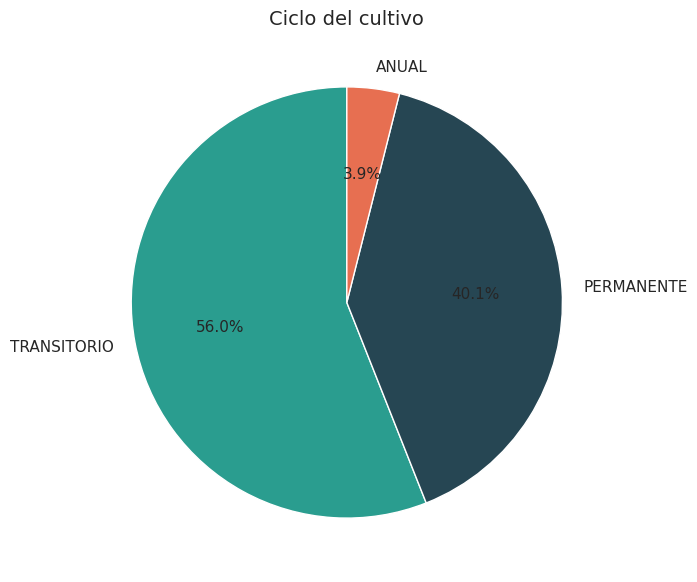

Frecuencia y porcentaje:
   TRANSITORIO : 206351 registros ( 56.0 %)
   PERMANENTE : 147644 registros ( 40.1 %)
   ANUAL : 14480 registros ( 3.9 %)


In [ ]:
# Ciclo del cultivo
conteo = datos["ciclo"].value_counts()
porcentaje = datos["ciclo"].value_counts(normalize=True) * 100

plt.figure(figsize=(7, 7))
plt.pie(conteo.values, labels=conteo.index, autopct="%1.1f%%",
        colors=[VERDE, AZUL, NARANJA], startangle=90)
plt.title("Ciclo del cultivo")
plt.show()

print("Frecuencia y porcentaje:")
for nombre in conteo.index:
    print("  ", nombre, ":", conteo[nombre], "registros (", round(porcentaje[nombre], 1), "%)")

La mayoría de los registros corresponde a cultivos **transitorios**, con **206.351 registros (56%)**, seguidos de los **permanentes** con **147.644 (40.1%)**. Los cultivos de ciclo **anual** son minoría, con apenas **14.480 registros (3.9%)**.

**Nota adicional:** esta distinción tambien explica por que existe `semestre`: los cultivos permanentes y anuales no se cosechan por semestre sino durante todo el ano, asi que cualquier modelo de prediccion debe condicionar el horizonte segun el ciclo del cultivo.

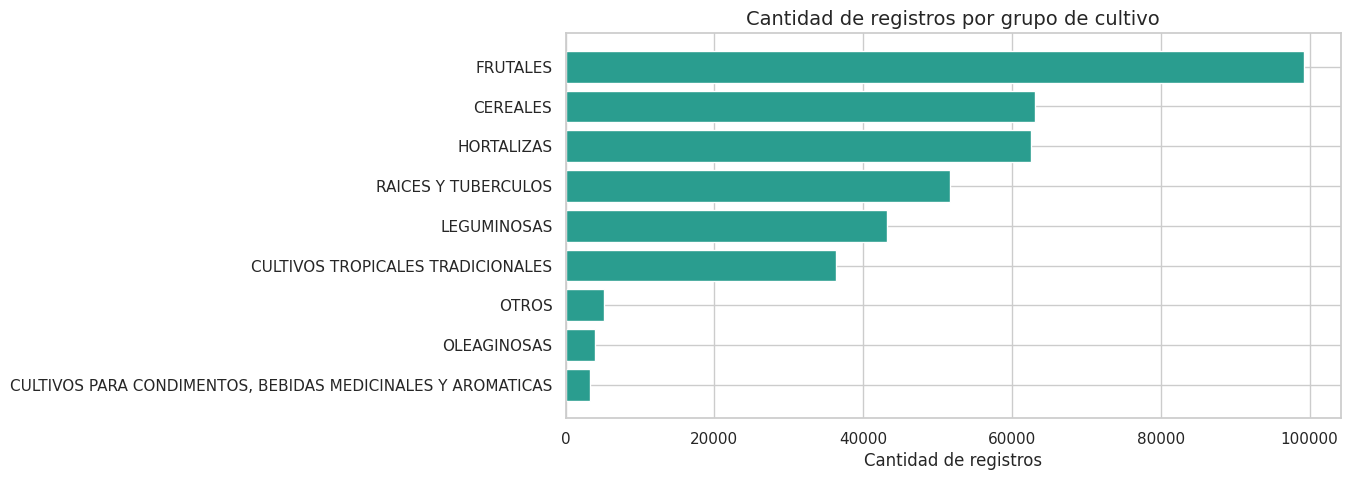

Frecuencia y porcentaje:
   FRUTALES : 99210 registros ( 26.9 %)
   CEREALES : 63065 registros ( 17.1 %)
   HORTALIZAS : 62623 registros ( 17.0 %)
   RAICES Y TUBERCULOS : 51627 registros ( 14.0 %)
   LEGUMINOSAS : 43245 registros ( 11.7 %)
   CULTIVOS TROPICALES TRADICIONALES : 36324 registros ( 9.9 %)
   OTROS : 5138 registros ( 1.4 %)
   OLEAGINOSAS : 3978 registros ( 1.1 %)
   CULTIVOS PARA CONDIMENTOS, BEBIDAS MEDICINALES Y AROMATICAS : 3265 registros ( 0.9 %)


In [ ]:
# Grupo de cultivo
conteo = datos["grupo"].value_counts()
porcentaje = datos["grupo"].value_counts(normalize=True) * 100

plt.figure(figsize=(10, 5))
plt.barh(conteo.index, conteo.values, color=VERDE)
plt.gca().invert_yaxis()
plt.title("Cantidad de registros por grupo de cultivo")
plt.xlabel("Cantidad de registros")
plt.show()

print("Frecuencia y porcentaje:")
for nombre in conteo.index:
    print("  ", nombre, ":", conteo[nombre], "registros (", round(porcentaje[nombre], 1), "%)")

El grupo con más registros es **Frutales**, con **99.210 registros (26.9%)**, seguido de **Cereales** (63.065, 17.1%) y **Hortalizas** (62.623, 17.0%). En el otro extremo, grupos como Oleaginosas y Cultivos para condimentos, bebidas medicinales y aromáticas representan menos del **1.5%** cada uno.

**Nota adicional:** esta clasificacion en 8 grupos es clave para el modelo porque, como se ve en la seccion de la variable objetivo, la escala tipica de area cosechada cambia radicalmente de un grupo a otro (oleaginosas y cultivos tropicales tienen medianas mucho mas altas que hortalizas, por ejemplo) — por eso `grupo` deberia ser una de las variables mas importantes del modelo.

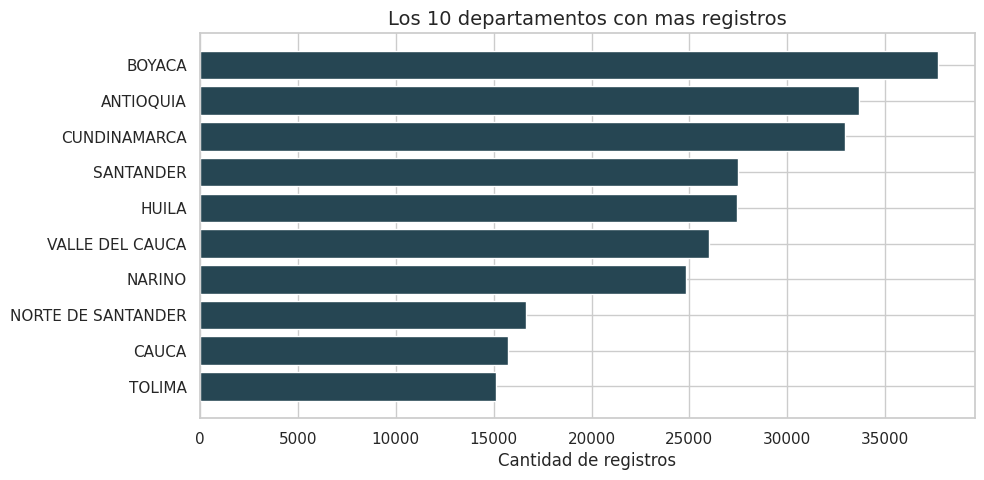

Total de departamentos: 32

   BOYACA : 37699 registros ( 10.2 %)
   ANTIOQUIA : 33637 registros ( 9.1 %)
   CUNDINAMARCA : 32954 registros ( 8.9 %)
   SANTANDER : 27488 registros ( 7.5 %)
   HUILA : 27409 registros ( 7.4 %)
   VALLE DEL CAUCA : 25982 registros ( 7.1 %)
   NARINO : 24812 registros ( 6.7 %)
   NORTE DE SANTANDER : 16669 registros ( 4.5 %)
   CAUCA : 15734 registros ( 4.3 %)
   TOLIMA : 15108 registros ( 4.1 %)


In [ ]:
# Departamentos con mas registros (son 32 en total, mostramos los 10 primeros)
conteo = datos["departamento"].value_counts().head(10)
porcentaje = datos["departamento"].value_counts(normalize=True).head(10) * 100

plt.figure(figsize=(10, 5))
plt.barh(conteo.index, conteo.values, color=AZUL)
plt.gca().invert_yaxis()
plt.title("Los 10 departamentos con mas registros")
plt.xlabel("Cantidad de registros")
plt.show()

print("Total de departamentos:", datos["departamento"].nunique())
print()
for nombre in conteo.index:
    print("  ", nombre, ":", conteo[nombre], "registros (", round(porcentaje[nombre], 1), "%)")

De los **32 departamentos**, **Boyacá** concentra la mayor cantidad de registros con **37.699 (10.2%)**, seguido de **Antioquia** (33.637, 9.1%) y **Cundinamarca** (32.954, 8.9%). Los 10 departamentos con más registros ya acumulan cerca del **70%** del total; los 22 restantes se reparten el otro 30%.

**Nota adicional:** esta alta concentracion geografica sugiere que el modelo podria beneficiarse de tratar los departamentos con mas registros de forma distinta a los que tienen poca informacion, en vez de asumir que todos aportan la misma calidad de senal.

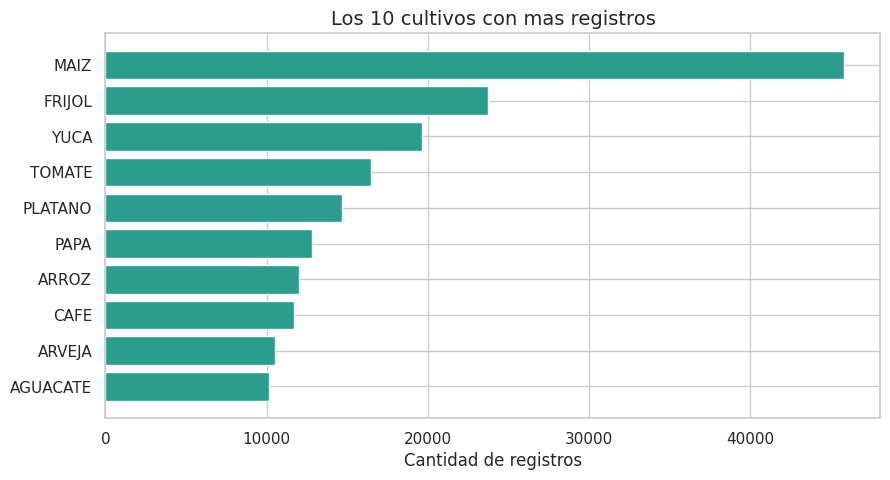

Total de cultivos diferentes: 248
Total de municipios diferentes: 1059

   MAIZ : 45796 registros ( 12.4 %)
   FRIJOL : 23753 registros ( 6.4 %)
   YUCA : 19612 registros ( 5.3 %)
   TOMATE : 16475 registros ( 4.5 %)
   PLATANO : 14700 registros ( 4.0 %)
   PAPA : 12785 registros ( 3.5 %)
   ARROZ : 11989 registros ( 3.3 %)
   CAFE : 11722 registros ( 3.2 %)
   ARVEJA : 10528 registros ( 2.9 %)
   AGUACATE : 10157 registros ( 2.8 %)


In [ ]:
# Cultivos con mas registros (hay mas de 200, mostramos los 10 primeros)
conteo = datos["cultivo"].value_counts().head(10)
porcentaje = datos["cultivo"].value_counts(normalize=True).head(10) * 100

plt.figure(figsize=(10, 5))
plt.barh(conteo.index, conteo.values, color=VERDE)
plt.gca().invert_yaxis()
plt.title("Los 10 cultivos con mas registros")
plt.xlabel("Cantidad de registros")
plt.show()

print("Total de cultivos diferentes:", datos["cultivo"].nunique())
print("Total de municipios diferentes:", datos["municipio"].nunique())
print()
for nombre in conteo.index:
    print("  ", nombre, ":", conteo[nombre], "registros (", round(porcentaje[nombre], 1), "%)")

De los **248 cultivos** distintos reportados en **1.059 municipios**, el **maíz** es el que más se registra, con **45.796 registros (12.4%)**, seguido de **fríjol** (23.753, 6.4%) y **yuca** (19.612, 5.3%). La actividad agrícola está concentrada en pocos cultivos frente al total disponible.

**Nota adicional:** que solo 3 cultivos (maiz, frijol, yuca) concentren el 24% de los registros implica que el modelo tendra mucha mas informacion para aprender sobre esos cultivos que sobre los ~240 restantes — algo a tener en cuenta al evaluar el desempeno por cultivo en la Fase 2, en vez de mirar solo un error promedio global.

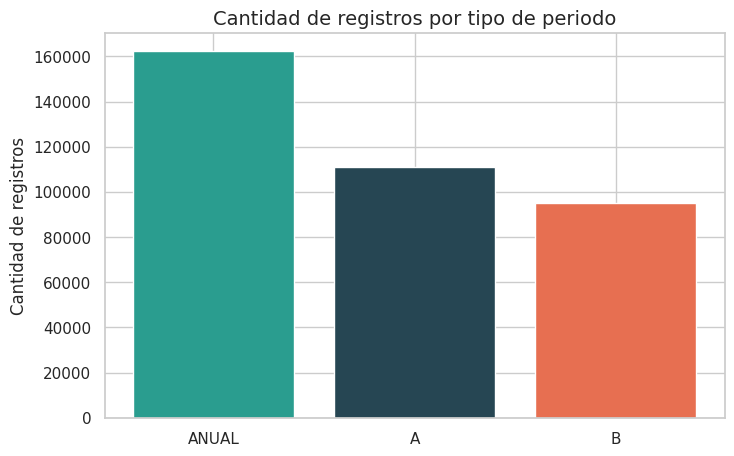

   ANUAL : 162354 registros ( 44.1 %)
   A : 110977 registros ( 30.1 %)
   B : 95144 registros ( 25.8 %)

Los reportes ANUALES son casi siempre de cultivos permanentes (cafe, cacao, platano),
que se cosechan durante todo el anio y no por semestres.


In [ ]:
# Tipo de periodo: semestre A, semestre B o reporte anual
conteo = datos["semestre"].value_counts()
porcentaje = datos["semestre"].value_counts(normalize=True) * 100

plt.figure(figsize=(8, 5))
plt.bar(conteo.index, conteo.values, color=[VERDE, AZUL, NARANJA])
plt.title("Cantidad de registros por tipo de periodo")
plt.ylabel("Cantidad de registros")
plt.show()

for nombre in conteo.index:
    print("  ", nombre, ":", conteo[nombre], "registros (", round(porcentaje[nombre], 1), "%)")
print()
print("Los reportes ANUALES son casi siempre de cultivos permanentes (cafe, cacao, platano),")
print("que se cosechan durante todo el anio y no por semestres.")

Un **44.1%** de los registros son reportes **anuales** (162.354), mientras que los semestres **A** y **B** representan **30.1%** (110.977) y **25.8%** (95.144) respectivamente. Los reportes anuales corresponden mayormente a cultivos permanentes, que no se cosechan por semestre sino durante todo el año.

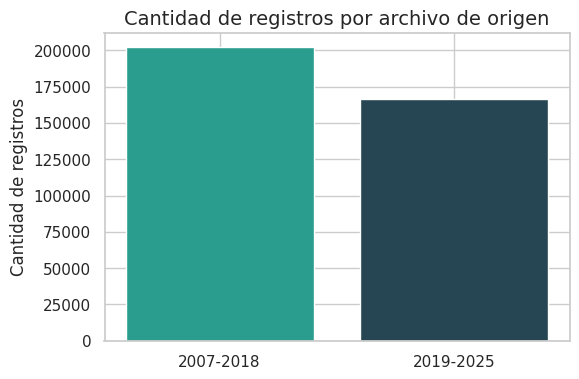

   2007-2018 : 201979 registros ( 54.8 %)
   2019-2025 : 166496 registros ( 45.2 %)


In [ ]:
# Fuente del archivo (solo 2 categorias)
conteo = datos["fuente"].value_counts()
porcentaje = datos["fuente"].value_counts(normalize=True) * 100

plt.figure(figsize=(6, 4))
plt.bar(conteo.index, conteo.values, color=[VERDE, AZUL])
plt.title("Cantidad de registros por archivo de origen")
plt.ylabel("Cantidad de registros")
plt.show()

for nombre in conteo.index:
    print("  ", nombre, ":", conteo[nombre], "registros (", round(porcentaje[nombre], 1), "%)")

El archivo viejo (2007-2018) aporta un poco más de la mitad de los registros: **201.979 (54.8%)**, frente a **166.496 (45.2%)** del archivo nuevo (2019-2025). Sin embargo el archivo nuevo cubre menos años (7 vs 12) y aun así tiene casi el mismo total — reporta a un ritmo mucho mayor (~23.800 registros/año vs ~16.800/año del archivo viejo), probablemente por mayor detalle geográfico.

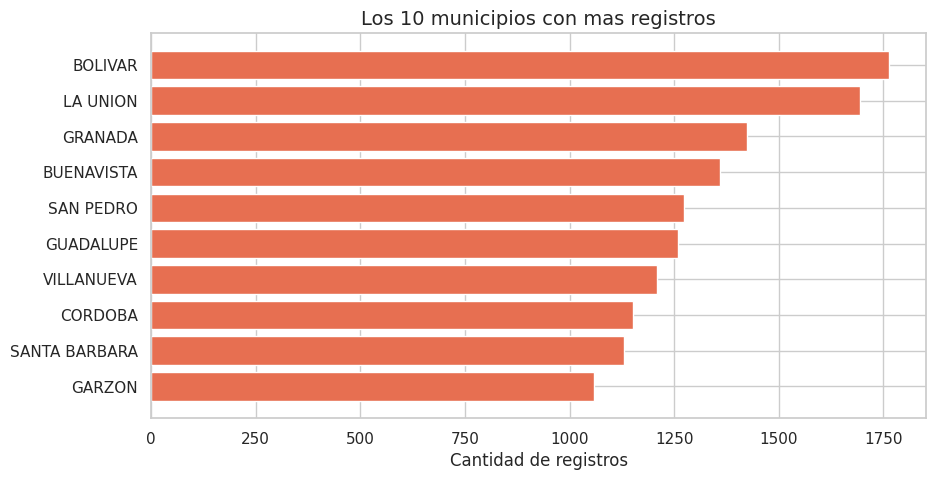

Total de municipios diferentes: 1059

   BOLIVAR : 1764 registros ( 0.48 %)
   LA UNION : 1695 registros ( 0.46 %)
   GRANADA : 1424 registros ( 0.39 %)
   BUENAVISTA : 1360 registros ( 0.37 %)
   SAN PEDRO : 1273 registros ( 0.35 %)
   GUADALUPE : 1259 registros ( 0.34 %)
   VILLANUEVA : 1209 registros ( 0.33 %)
   CORDOBA : 1151 registros ( 0.31 %)
   SANTA BARBARA : 1130 registros ( 0.31 %)
   GARZON : 1059 registros ( 0.29 %)


In [ ]:
# Municipio: hay 1059, mismo criterio que usamos con cultivo (top 10)
conteo = datos["municipio"].value_counts().head(10)
porcentaje = datos["municipio"].value_counts(normalize=True).head(10) * 100

plt.figure(figsize=(10, 5))
plt.barh(conteo.index, conteo.values, color=NARANJA)
plt.gca().invert_yaxis()
plt.title("Los 10 municipios con mas registros")
plt.xlabel("Cantidad de registros")
plt.show()

print("Total de municipios diferentes:", datos["municipio"].nunique())
print()
for nombre in conteo.index:
    print("  ", nombre, ":", conteo[nombre], "registros (", round(porcentaje[nombre], 2), "%)")

Hay **1.059 municipios** distintos, y a diferencia de `departamento` o `cultivo`, aquí ninguno domina: el municipio con más registros (**Bolívar**) apenas representa el **0.48%** del total, y entre los 10 municipios más frecuentes suman menos del **4%** combinados. Esto confirma que `municipio` está demasiado fragmentado para usarse solo como predictor — `departamento` es el nivel de agregación que sí tiene sentido.

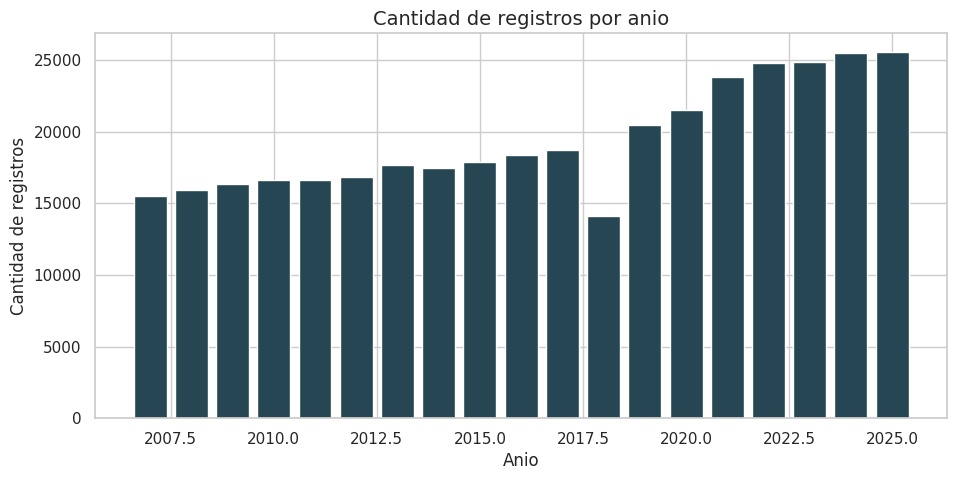

Rango: 2007 a 2025
Minimo de registros: 14090 (anio 2018 )
Maximo de registros: 25584 (anio 2025 )


In [ ]:
# Anio: es numerica pero no tiene sentido calcular asimetria/promedio de un anio,
# la mostramos como cantidad de registros por anio (igual que hicimos con semestre)
conteo = datos["anio"].value_counts().sort_index()

plt.figure(figsize=(11, 5))
plt.bar(conteo.index.astype(int), conteo.values, color=AZUL)
plt.title("Cantidad de registros por anio")
plt.xlabel("Anio")
plt.ylabel("Cantidad de registros")
plt.show()

print("Rango:", int(datos['anio'].min()), "a", int(datos['anio'].max()))
print("Minimo de registros:", conteo.min(), "(anio", conteo.idxmin(), ")")
print("Maximo de registros:", conteo.max(), "(anio", conteo.idxmax(), ")")

`anio` va de **2007 a 2025**. La cantidad de registros por año crece de forma sostenida: de **15.483 en 2007** a **25.584 en 2025** (casi se duplica), coincidiendo con lo que vimos en `fuente` — el país empieza a reportar con más detalle geográfico en años recientes. La excepción es **2018**, con solo **14.090 registros** — el año con menos reportes de toda la serie, justo el último año del archivo viejo, probablemente quedó incompleto en la fuente original.

**Nota adicional:** esto es importante para la Fase 2 al construir series de tiempo por anio — 2018 en particular deberia tratarse con cuidado o excluirse de los promedios historicos por su reporte incompleto.

---
### Correlaciones y patrones interesantes (variables generales)

Mas alla de la frecuencia de cada variable por separado, aparecen tres patrones al cruzarlas:

1. **El tipo de reporte (`semestre`) esta determinado casi por completo por `ciclo`.** El
   44.1% de los registros son reportes anuales (162.354 filas), y esos corresponden
   mayormente a cultivos **permanentes** (cafe, cacao, platano), que no se cosechan por
   semestre sino durante todo el anio. Esto significa que `ciclo` y `semestre` no son dos
   fuentes de informacion independientes — cualquier modelo que use ambas debe tener en
   cuenta que estan relacionadas.

2. **Los dos archivos no solo difieren en cantidad de filas, sino en ritmo de reporte.** El
   archivo viejo (2007-2018, 12 anios) aporta el 54.8% de las filas; el nuevo (2019-2025, solo
   7 anios) aporta el 45.2% — es decir, reporta casi el doble de rapido (~23.800 filas/anio
   frente a ~16.800/anio). Junto con el hallazgo de la seccion de limpieza de que el archivo
   nuevo tambien concentra muchos mas errores del tipo "cosechado > sembrado" (7.92% frente a
   0.03% del archivo viejo), esto sugiere que el cambio de metodologia o de formulario de
   captura entre los dos periodos no solo agrego mas detalle geografico, sino que tambien
   cambio la forma de diligenciar los datos — algo que la Fase 2 debe tener en cuenta al
   decidir si usar los dos archivos juntos o por separado.

3. **La actividad agricola esta concentrada en pocos departamentos y cultivos, pero no en
   pocos municipios.** Los 10 departamentos mas frecuentes ya acumulan cerca del 70% del total
   de registros, y el maiz, frijol y yuca concentran el 24% de todos los registros de cultivo —
   pero ningun municipio individual supera el 0.5% del total. Esto es un patron util para el
   modelo: `departamento` y `cultivo` son buenos niveles de agregacion (concentran senal),
   mientras que `municipio` es demasiado granular para usarse solo, y probablemente aporte mas
   como variable adicional que como predictor principal.


## 4.2 Variables numericas

Para cada variable numerica graficamos el histograma y el boxplot, y reportamos la estadistica
que corresponda segun la forma que tenga.

In [ ]:
# Funcion sencilla para describir una variable numerica
def describir_numerica(columna, nombre, unidad):
    valores = columna.dropna()
    asimetria = valores.skew()

    figura, ejes = plt.subplots(1, 2, figsize=(13, 4))

    limite = valores.quantile(0.95)
    ejes[0].hist(valores[valores <= limite], bins=50, color=VERDE, edgecolor="white")
    ejes[0].set_title("Histograma de " + nombre)
    ejes[0].set_xlabel(unidad)
    ejes[0].set_ylabel("Cantidad de registros")

    if abs(asimetria) >= 1:
        # Variable muy sesgada: calculamos el boxplot SOBRE el logaritmo, no solo
        # cambiamos la escala del eje. Asi los outliers se calculan bien y no
        # sale la mancha negra.
        valores_log = np.log1p(valores)
        sns.boxplot(x=valores_log, ax=ejes[1], color=VERDE)
        ejes[1].set_title("Boxplot de " + nombre + " (escala log)")
        ejes[1].set_xlabel("log(1 + " + unidad + ")")
    else:
        sns.boxplot(x=valores, ax=ejes[1], color=VERDE)
        ejes[1].set_title("Boxplot de " + nombre)
        ejes[1].set_xlabel(unidad)

    plt.tight_layout()
    plt.show()

    print("Asimetria:", round(asimetria, 2))
    if abs(asimetria) < 0.5:
        print("La distribucion es SIMETRICA, entonces reportamos promedio y desviacion estandar:")
        print("  ", nombre, "=", round(valores.mean(), 2), "+/-", round(valores.std(), 2), unidad)
    else:
        print("La distribucion es ASIMETRICA, entonces reportamos mediana y rango intercuartil:")
        print("  mediana =", round(valores.median(), 2), unidad)
        print("  rango intercuartil =", round(valores.quantile(0.25), 2), "a",
              round(valores.quantile(0.75), 2), unidad)
        print("  rango total =", round(valores.min(), 2), "a", round(valores.max(), 2), unidad)

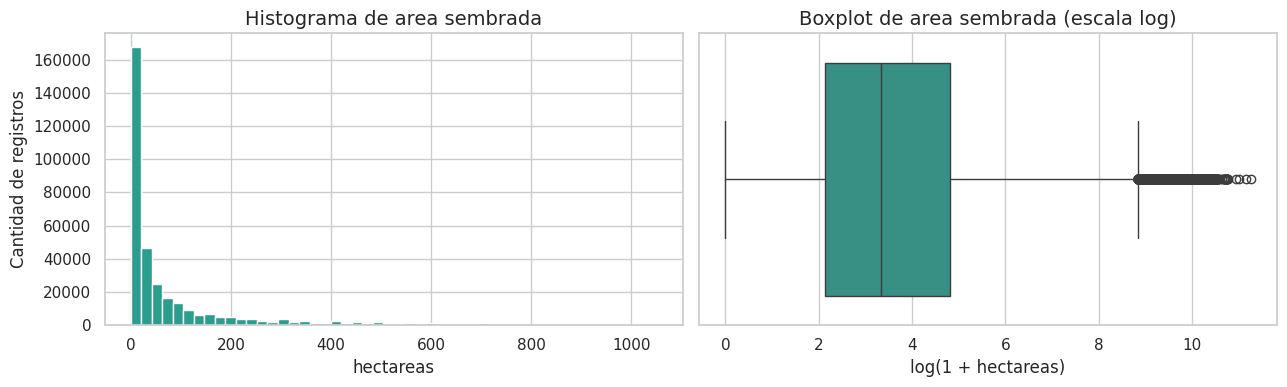

Asimetria: 16.54
La distribucion es ASIMETRICA, entonces reportamos mediana y rango intercuartil:
  mediana = 27.3 hectareas
  rango intercuartil = 7.5 a 123.0 hectareas
  rango total = 0.0 a 77630.0 hectareas


In [ ]:
describir_numerica(datos["area_sembrada"], "area sembrada", "hectareas")

 El **área sembrada** es una variable numérica **asimétrica** (asimetría = 16.54): la mediana es de **27.3 hectáreas**, con un rango intercuartil de **7.5 a 123 hectáreas**. El máximo llega a **77.630 hectáreas**, así que se reporta con mediana y rango intercuartil, no con promedio.

**Nota adicional:** esta es, de las variables generales, la que mas se relaciona con la variable objetivo (se retoma con el numero exacto de correlacion en la seccion de area cosechada).

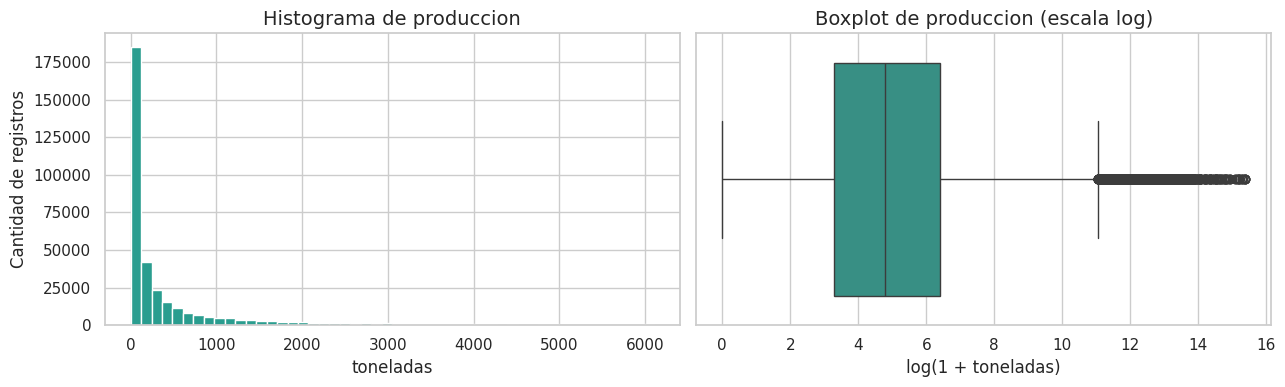

Asimetria: 56.01
La distribucion es ASIMETRICA, entonces reportamos mediana y rango intercuartil:
  mediana = 120.0 toneladas
  rango intercuartil = 26.0 a 600.0 toneladas
  rango total = 0.0 a 4776340.5 toneladas


In [ ]:
describir_numerica(datos["produccion"], "produccion", "toneladas")

La **producción** también es fuertemente asimétrica (asimetría = 56.01): la mediana es de **120 toneladas**, con un rango intercuartil de **26 a 600 toneladas**. El valor máximo (**4.776.340 toneladas**) es un caso extremo que confirma que el promedio no representa bien esta variable.

**Nota adicional:** recordemos que `produccion` no se usa como variable objetivo porque depende matematicamente de `area_cosechada x rendimiento` — se mantiene aqui solo como variable de referencia, no como algo que el modelo deba predecir.

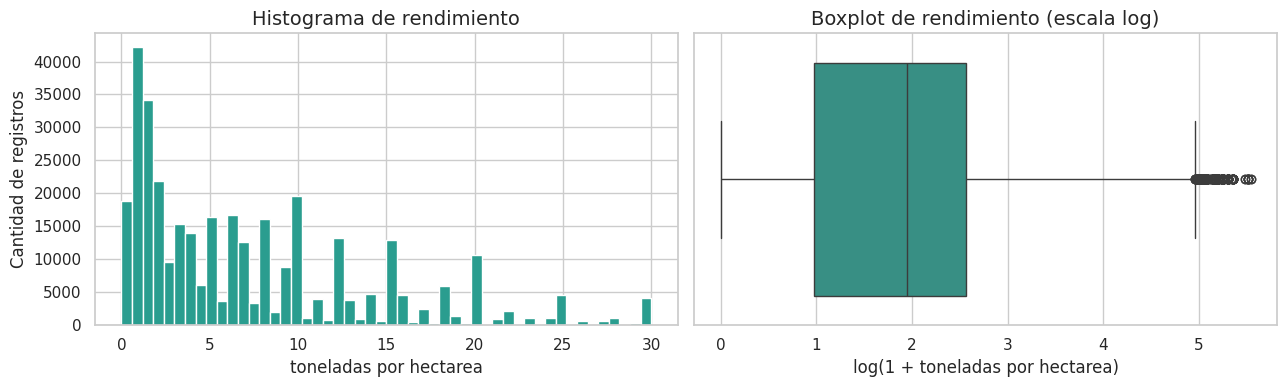

Asimetria: 4.78
La distribucion es ASIMETRICA, entonces reportamos mediana y rango intercuartil:
  mediana = 6.0 toneladas por hectarea
  rango intercuartil = 1.64 a 12.0 toneladas por hectarea
  rango total = 0.0 a 253.0 toneladas por hectarea


In [ ]:
describir_numerica(datos["rendimiento"], "rendimiento", "toneladas por hectarea")

El **rendimiento** (t/ha) tiene una asimetría de **4.78**: la mediana es de **6 t/ha**, con rango intercuartil de **1.64 a 12 t/ha**. Aunque menos extrema que las otras dos variables, sigue siendo asimétrica, así que se reporta igual con mediana y rango intercuartil.

**Nota adicional:** al ser la menos asimetrica de las tres, `rendimiento` es tambien la que mas se acerca a poder modelarse de forma directa (sin transformacion logaritmica), algo util si en la Fase 2 se explora la via indirecta (rendimiento x area cosechada = produccion).

In [ ]:
# Tabla resumen de todas las variables numericas (para pasarla a las diapositivas)
resumen = datos[["area_sembrada", "area_cosechada", "produccion", "rendimiento"]].describe().T
resumen["asimetria"] = datos[["area_sembrada", "area_cosechada",
                              "produccion", "rendimiento"]].skew()
resumen = resumen.round(2)
resumen

,count,mean,std,min,25%,50%,75%,max,asimetria
area_sembrada,"368,475.00",263.92,"1,176.79",0.00,7.50,27.30,123.00,"77,630.00",16.54
area_cosechada,"368,475.00",231.93,"1,049.94",0.00,6.00,22.50,103.94,"77,630.00",16.94
produccion,"368,475.00","2,992.51","47,280.59",0.00,26.00,120.00,600.00,"4,776,340.50",56.01
rendimiento,"365,045.00",9.88,15.24,0.00,1.64,6.00,12.00,253.00,4.78


---
# 5. Variable objetivo: Area cosechada

**Que es:** el area cosechada son las hectareas que realmente se recogieron de un cultivo en un
municipio durante un periodo.

**En que se diferencia del area sembrada:** el area sembrada es lo que se planto. La diferencia
entre las dos es lo que se perdio por clima, plagas o problemas en la cosecha. Por eso el area
cosechada es la que muestra la produccion real del pais.

**Que queremos predecir en las fases 2 y 3:** dado un municipio, un cultivo y un periodo,
estimar cuantas hectareas se van a cosechar. Como es un numero, es un problema de regresion.

## Valores imposibles

Revisamos tres reglas que siempre se deben cumplir en un cultivo:

1. No se puede cosechar mas de lo que se sembro.
2. No puede haber produccion si no se cosecho nada.
3. El area cosechada en cero significa que se perdio toda la cosecha (o que no reportaron).


In [ ]:
# Contamos cuantas filas rompen cada regla
regla_1 = datos["area_cosechada"] > datos["area_sembrada"]
regla_2 = (datos["produccion"] > 0) & (datos["area_cosechada"] == 0)
regla_3 = datos["area_cosechada"] == 0

print("PROBLEMAS ENCONTRADOS")
print()
print("1. Cosecharon mas de lo que sembraron :", regla_1.sum(), "filas",
      "(", round(regla_1.mean() * 100, 2), "%)")
print("2. Hay produccion pero area cosechada 0:", regla_2.sum(), "filas",
      "(", round(regla_2.mean() * 100, 2), "%)")
print("3. Area cosechada igual a cero        :", regla_3.sum(), "filas",
      "(", round(regla_3.mean() * 100, 2), "%)")

PROBLEMAS ENCONTRADOS

1. Cosecharon mas de lo que sembraron : 13253 filas ( 3.6 %)
2. Hay produccion pero area cosechada 0: 717 filas ( 0.19 %)
3. Area cosechada igual a cero        : 11433 filas ( 3.1 %)


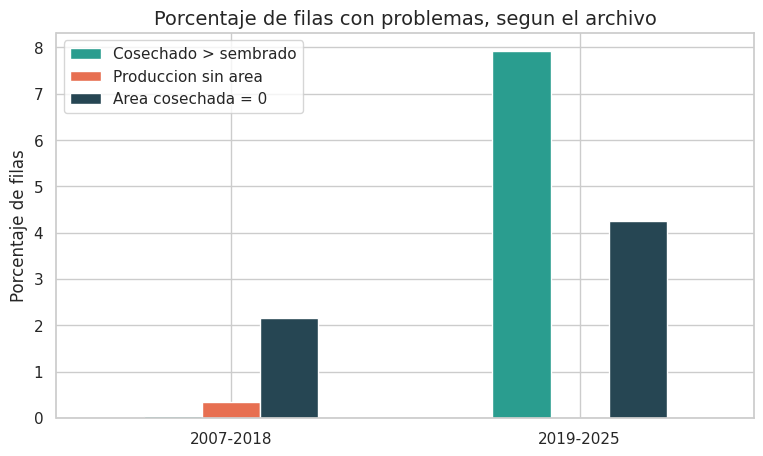

           problema_1  problema_2  problema_3
fuente                                       
2007-2018        0.03        0.35        2.15
2019-2025        7.92        0.00        4.26


In [ ]:
# GRAFICA LIMPIEZA DATOS AFINES A VARIABLE OBJETIVO
datos["problema_1"] = regla_1
datos["problema_2"] = regla_2
datos["problema_3"] = regla_3

comparacion = datos.groupby("fuente")[["problema_1", "problema_2", "problema_3"]].mean() * 100
comparacion = comparacion.round(2)

comparacion.plot(kind="bar", figsize=(9, 5), color=[VERDE, NARANJA, AZUL])
plt.title("Porcentaje de filas con problemas, segun el archivo")
plt.ylabel("Porcentaje de filas")
plt.xlabel("")
plt.xticks(rotation=0)
plt.legend(["Cosechado > sembrado", "Produccion sin area", "Area cosechada = 0"])
plt.show()

print(comparacion)

**Hallazgo importante:** los problemas no estan repartidos igual entre los dos archivos.

En el archivo nuevo (2019-2025) hay muchas mas filas donde el area cosechada es mayor que la
sembrada. Esto pasa sobre todo en cultivos transitorios y probablemente se debe a que cambiaron
la forma de diligenciar el formulario: reportan el area sembrada del semestre, pero el area
cosechada incluye siembras del semestre anterior.

Por eso la columna `fuente` es importante y hay que tenerla en cuenta en la Fase 2.

## Que decidimos hacer con los datos problematicos

| Problema | Decision | Por que |
|---|---|---|
| Cosechado mayor que sembrado | **Borrar esas filas** | Es fisicamente imposible, el dato esta mal |
| Produccion sin area cosechada | **Borrar esas filas** | Tambien es imposible |
| Area cosechada igual a cero | **Dejarlas por ahora** | Puede ser una perdida real de la cosecha; lo decidimos en la Fase 2 |
| Valores muy grandes (outliers) | **Dejarlos** | Son municipios grandes de verdad, no errores (lo revisamos abajo) |
| Rendimiento faltante | **Dejarlo** | Se puede recalcular en la Fase 2 con produccion / area cosechada |

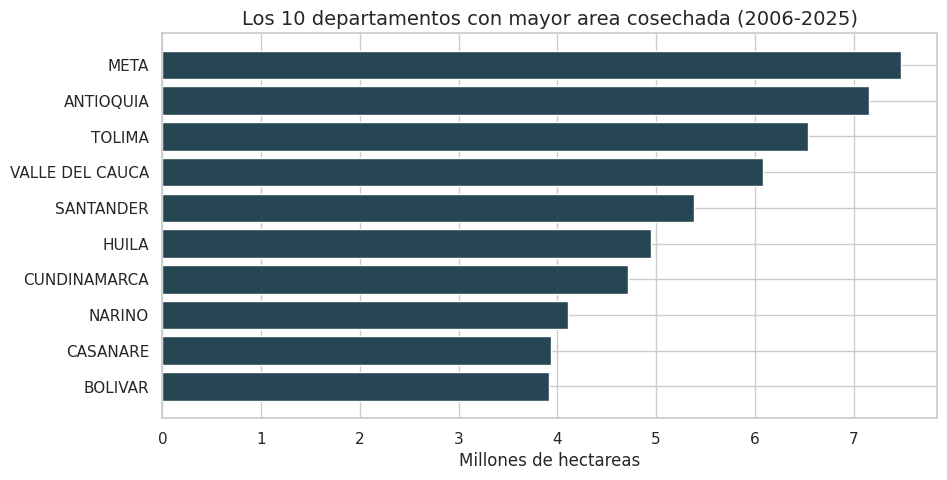

In [ ]:
# Los 10 departamentos con mas area cosechada
top_departamentos = datos.groupby("departamento")["area_cosechada"].sum().nlargest(10)

plt.figure(figsize=(10, 5))
plt.barh(top_departamentos.index, top_departamentos.values / 1000000, color=AZUL)
plt.gca().invert_yaxis()
plt.title("Los 10 departamentos con mayor area cosechada (2006-2025)")
plt.xlabel("Millones de hectareas")
plt.show()

In [ ]:
# Antes de borrar, revisamos si los valores mas grandes son errores o son reales
mas_grandes = datos.nlargest(10, "area_cosechada")
mas_grandes[["anio", "departamento", "municipio", "cultivo",
             "area_sembrada", "area_cosechada", "produccion"]]

,anio,departamento,municipio,cultivo,area_sembrada,area_cosechada,produccion
308219,2025,META,PUERTO GAITAN,SOYA,"1,500.00","77,630.00","194,075.00"
308215,2023,META,PUERTO GAITAN,SOYA,"1,000.00","61,000.00","137,250.00"
308217,2024,META,PUERTO GAITAN,SOYA,"1,200.00","57,000.00","128,250.00"
342271,2022,SANTANDER,PUERTO WILCHES,PALMA DE ACEITE,"46,307.00","46,264.00","222,067.20"
342272,2023,SANTANDER,PUERTO WILCHES,PALMA DE ACEITE,"46,312.00","46,212.00","221,817.60"
342273,2024,SANTANDER,PUERTO WILCHES,PALMA DE ACEITE,"46,312.00","46,212.00","221,817.60"
342274,2025,SANTANDER,PUERTO WILCHES,PALMA DE ACEITE,"46,312.00","46,212.00","224,128.20"
342270,2021,SANTANDER,PUERTO WILCHES,PALMA DE ACEITE,"46,350.00","45,000.00","216,000.00"
342269,2020,SANTANDER,PUERTO WILCHES,PALMA DE ACEITE,"45,000.00","38,702.00","185,769.60"
144945,2011,META,SAN CARLOS DE GUAROA,PALMA DE ACEITE,"43,600.00","38,600.00","115,800.00"


Al mirar la tabla se ven dos casos muy distintos:

- **La soya de Puerto Gaitan (Meta)** aparece con 1.500 hectareas sembradas y 77.630 cosechadas.
  Eso es imposible: se cosecho 50 veces mas de lo que se sembro. **Es un error de digitacion**
  y lo vamos a eliminar con la regla 1.
- **La palma de Puerto Wilches (Santander)** aparece con 46.312 sembradas y 46.212 cosechadas.
  Eso si tiene sentido: es un municipio palmero enorme. **Es un dato real** aunque el boxplot
  lo marque como valor atipico, y por eso lo conservamos.

Esto muestra por que no se pueden borrar los valores atipicos solo por ser grandes: hay que
revisarlos. Si borraramos todos los valores altos, perderiamos justamente los municipios que
mas producen en el pais.

In [ ]:
# Creamos la tabla limpia quitando solo las filas imposibles
datos_limpios = datos[(datos["area_cosechada"] <= datos["area_sembrada"]) &
                      ~((datos["produccion"] > 0) & (datos["area_cosechada"] == 0))]

datos_limpios = datos_limpios.copy()

print("Filas antes de limpiar :", len(datos))
print("Filas despues de limpiar:", len(datos_limpios))
print("Filas eliminadas        :", len(datos) - len(datos_limpios),
      "(", round((len(datos) - len(datos_limpios)) / len(datos) * 100, 2), "% del total )")

Filas antes de limpiar : 368475
Filas despues de limpiar: 354505
Filas eliminadas        : 13970 ( 3.79 % del total )


In [ ]:
# Volvemos a mirar los valores mas grandes: ahora todos tienen sentido
datos_limpios.nlargest(10, "area_cosechada")[["anio", "departamento", "municipio", "cultivo",
                                              "area_sembrada", "area_cosechada", "produccion"]]

,anio,departamento,municipio,cultivo,area_sembrada,area_cosechada,produccion
342271,2022,SANTANDER,PUERTO WILCHES,PALMA DE ACEITE,"46,307.00","46,264.00","222,067.20"
342272,2023,SANTANDER,PUERTO WILCHES,PALMA DE ACEITE,"46,312.00","46,212.00","221,817.60"
342273,2024,SANTANDER,PUERTO WILCHES,PALMA DE ACEITE,"46,312.00","46,212.00","221,817.60"
342274,2025,SANTANDER,PUERTO WILCHES,PALMA DE ACEITE,"46,312.00","46,212.00","224,128.20"
342270,2021,SANTANDER,PUERTO WILCHES,PALMA DE ACEITE,"46,350.00","45,000.00","216,000.00"
342269,2020,SANTANDER,PUERTO WILCHES,PALMA DE ACEITE,"45,000.00","38,702.00","185,769.60"
144945,2011,META,SAN CARLOS DE GUAROA,PALMA DE ACEITE,"43,600.00","38,600.00","115,800.00"
368326,2021,CASANARE,PAZ DE ARIPORO,ARROZ,"37,418.00","37,418.00","202,057.20"
342268,2019,SANTANDER,PUERTO WILCHES,PALMA DE ACEITE,"38,702.00","37,000.00","177,600.00"
368324,2020,CASANARE,PAZ DE ARIPORO,ARROZ,"35,958.00","35,958.00","194,448.00"


In [ ]:
# Estadisticas basicas de la variable objetivo
print("ESTADISTICAS DEL AREA COSECHADA (hectareas)")
print()
print("Cantidad de datos :", len(datos))
print("Valores faltantes :", datos["area_cosechada"].isna().sum())
print("Valores en cero   :", (datos["area_cosechada"] == 0).sum())
print()
print("Minimo            :", round(datos["area_cosechada"].min(), 2))
print("Promedio (media)  :", round(datos["area_cosechada"].mean(), 2))
print("Mediana           :", round(datos["area_cosechada"].median(), 2))
print("Maximo            :", round(datos["area_cosechada"].max(), 2))
print()
print("Cuartil 1 (25%)   :", round(datos["area_cosechada"].quantile(0.25), 2))
print("Cuartil 3 (75%)   :", round(datos["area_cosechada"].quantile(0.75), 2))


ESTADISTICAS DEL AREA COSECHADA (hectareas)

Cantidad de datos : 368475
Valores faltantes : 0
Valores en cero   : 11433

Minimo            : 0.0
Promedio (media)  : 231.93
Mediana           : 22.5
Maximo            : 77630.0

Cuartil 1 (25%)   : 6.0
Cuartil 3 (75%)   : 103.94


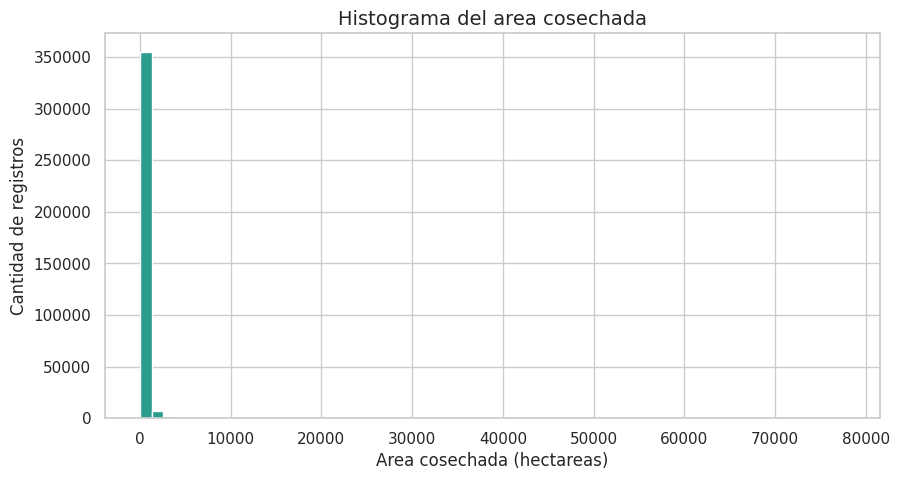

Casi todas las barras se acumulan en el cero porque hay unos pocos municipios
con miles de hectareas que estiran el eje. La grafica esta sesgada a la derecha.


In [ ]:
# Primero graficamos, y despues decidimos que estadistica reportar
plt.figure(figsize=(10, 5))
plt.hist(datos["area_cosechada"], bins=60, color=VERDE, edgecolor="white")
plt.title("Histograma del area cosechada")
plt.xlabel("Area cosechada (hectareas)")
plt.ylabel("Cantidad de registros")
plt.show()

print("Casi todas las barras se acumulan en el cero porque hay unos pocos municipios")
print("con miles de hectareas que estiran el eje. La grafica esta sesgada a la derecha.")

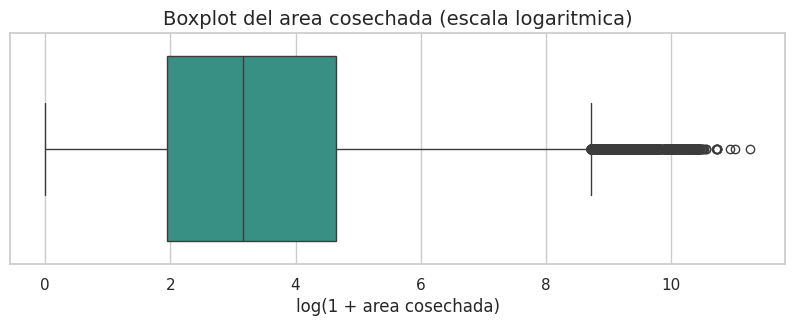

En escala normal el boxplot se ve aplastado contra el cero porque unos pocos
municipios con miles de hectareas estiran el eje. Usando el logaritmo se puede
ver bien la caja, la mediana y los bigotes.


In [ ]:
# El boxplot confirma lo mismo: la caja queda aplastada contra el cero
# Calculamos el log aqui (antes se calculaba mas adelante, lo adelantamos para el boxplot)
datos["area_log"] = np.log1p(datos["area_cosechada"])

plt.figure(figsize=(10, 3))
sns.boxplot(x=datos["area_log"], color=VERDE)
plt.title("Boxplot del area cosechada (escala logaritmica)")
plt.xlabel("log(1 + area cosechada)")
plt.show()

print("En escala normal el boxplot se ve aplastado contra el cero porque unos pocos")
print("municipios con miles de hectareas estiran el eje. Usando el logaritmo se puede")
print("ver bien la caja, la mediana y los bigotes.")

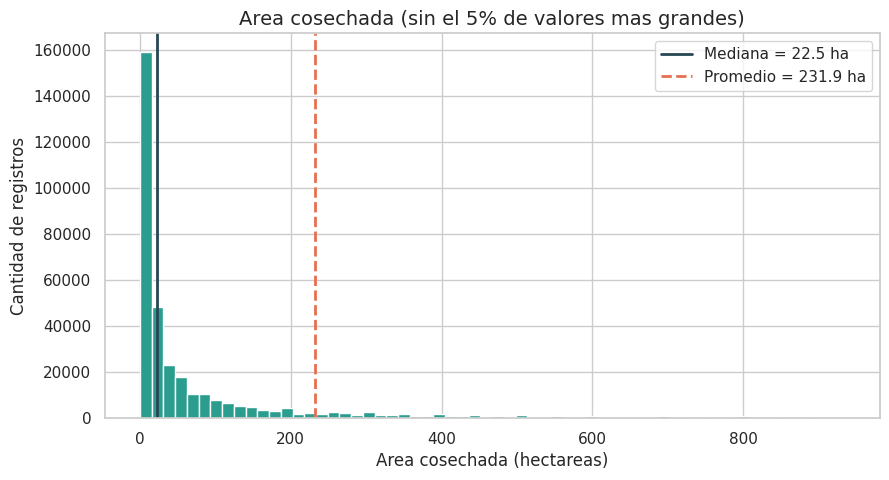

El promedio es mucho mas grande que la mediana.
Eso pasa porque los municipios muy grandes jalan el promedio hacia arriba.


In [ ]:
# Para verla mejor, graficamos solo el 95% de los datos mas pequeños
limite = datos["area_cosechada"].quantile(0.95)
datos_recortados = datos[datos["area_cosechada"] <= limite]

plt.figure(figsize=(10, 5))
plt.hist(datos_recortados["area_cosechada"], bins=60, color=VERDE, edgecolor="white")
plt.axvline(datos["area_cosechada"].median(), color=AZUL, linewidth=2,
            label="Mediana = " + str(round(datos["area_cosechada"].median(), 1)) + " ha")
plt.axvline(datos["area_cosechada"].mean(), color=NARANJA, linewidth=2, linestyle="--",
            label="Promedio = " + str(round(datos["area_cosechada"].mean(), 1)) + " ha")
plt.title("Area cosechada (sin el 5% de valores mas grandes)")
plt.xlabel("Area cosechada (hectareas)")
plt.ylabel("Cantidad de registros")
plt.legend()
plt.show()

print("El promedio es mucho mas grande que la mediana.")
print("Eso pasa porque los municipios muy grandes jalan el promedio hacia arriba.")

### Conclusion: como reportamos esta variable

Siguiendo la regla del parcial, la variable objetivo es **numerica asimetrica**:

- El histograma esta inclinado hacia un lado y el boxplot tiene muchos puntos lejos de la caja.
- El promedio (231 ha) es diez veces la mediana (23 ha), asi que el promedio no representa a
  un municipio tipico.

Entonces la reportamos con **mediana y rango intercuartil**, no con promedio y desviacion estandar:

> El area cosechada tiene una mediana de **23 hectareas** y un rango intercuartil de
> **6 a 104 hectareas** (el 50% de los municipios esta en ese rango). El rango total va de
> **0 a 77.630 hectareas**.

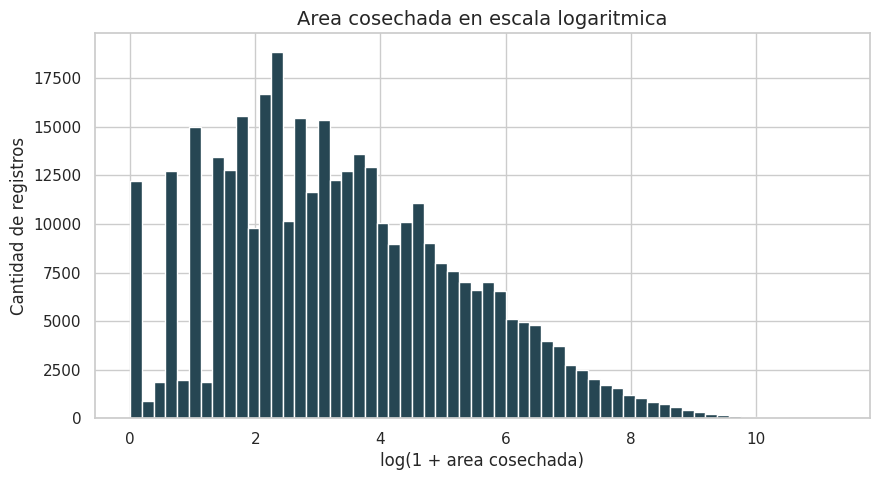

Con el logaritmo la distribucion se ve como una campana.
Esto nos servira en la Fase 2 para entrenar el modelo.


In [ ]:
# Como la variable esta tan sesgada, muchas veces se usa el logaritmo para verla mejor.
# El logaritmo comprime los valores grandes y deja ver la forma real de la distribucion.
datos["area_log"] = np.log1p(datos["area_cosechada"])

plt.figure(figsize=(10, 5))
plt.hist(datos["area_log"], bins=60, color=AZUL, edgecolor="white")
plt.title("Area cosechada en escala logaritmica")
plt.xlabel("log(1 + area cosechada)")
plt.ylabel("Cantidad de registros")
plt.show()

print("Con el logaritmo la distribucion se ve como una campana.")
print("Esto nos servira en la Fase 2 para entrenar el modelo.")

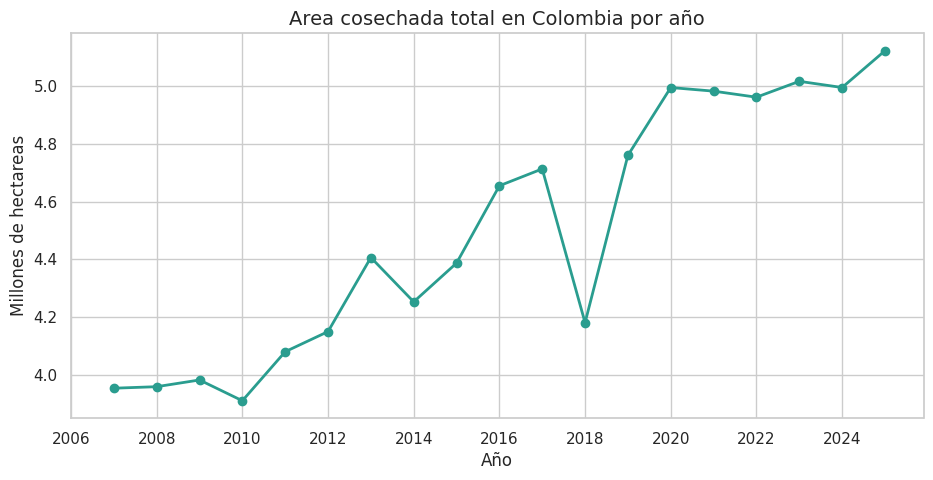

Nota: el anio 2007 y el 2018 tienen menos registros que los demas,
por eso aparecen mas bajos en la grafica.


In [ ]:
# Como ha cambiado el area cosechada total del pais anio por año
area_por_anio = datos.groupby("anio")["area_cosechada"].sum()

plt.figure(figsize=(11, 5))
plt.plot(area_por_anio.index, area_por_anio.values / 1000000, marker="o", color=VERDE, linewidth=2)
plt.title("Area cosechada total en Colombia por año")
plt.xlabel("Año")
plt.ylabel("Millones de hectareas")
plt.xticks(range(2006, 2026, 2))
plt.show()

print("Nota: el anio 2007 y el 2018 tienen menos registros que los demas,")
print("por eso aparecen mas bajos en la grafica.")

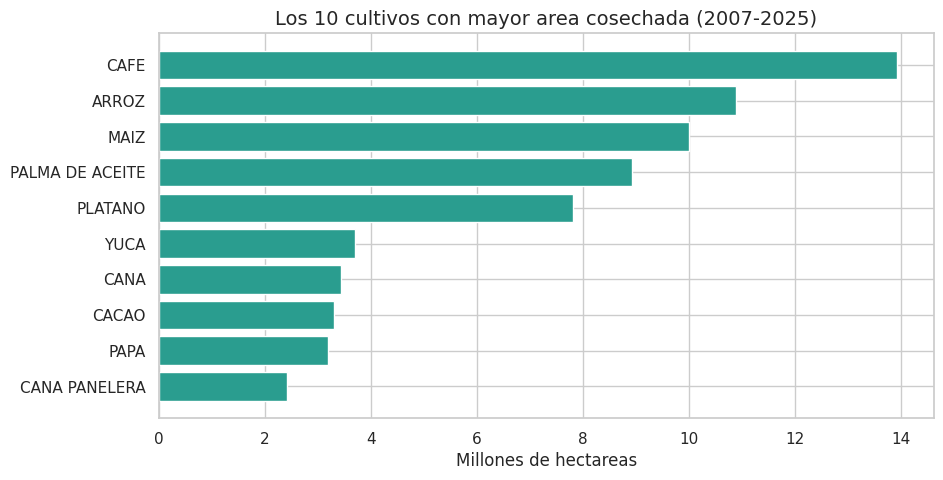

In [ ]:
# Los 10 cultivos con mayor area cosechada en total
top_cultivos = datos.groupby("cultivo")["area_cosechada"].sum().nlargest(10)

plt.figure(figsize=(10, 5))
plt.barh(top_cultivos.index, top_cultivos.values / 1000000, color=VERDE)
plt.gca().invert_yaxis()
plt.title("Los 10 cultivos con mayor area cosechada (2007-2025)")
plt.xlabel("Millones de hectareas")
plt.show()

In [ ]:
# Grafica interactiva: cuanto aporta cada departamento
aporte = datos_limpios.groupby("departamento", as_index=False)["area_cosechada"].sum()
aporte = aporte.nlargest(15, "area_cosechada")

figura = px.bar(
    aporte,
    x="area_cosechada",
    y="departamento",
    orientation="h",
    title="Los 15 departamentos con mayor area cosechada",
    labels={"area_cosechada": "Area cosechada (hectareas)", "departamento": ""},
    color_discrete_sequence=["#2E7D32"]  # Verde sólido uniforme para todas las barras
)

figura.update_layout(yaxis={"categoryorder": "total ascending"}, height=600)
figura.show()

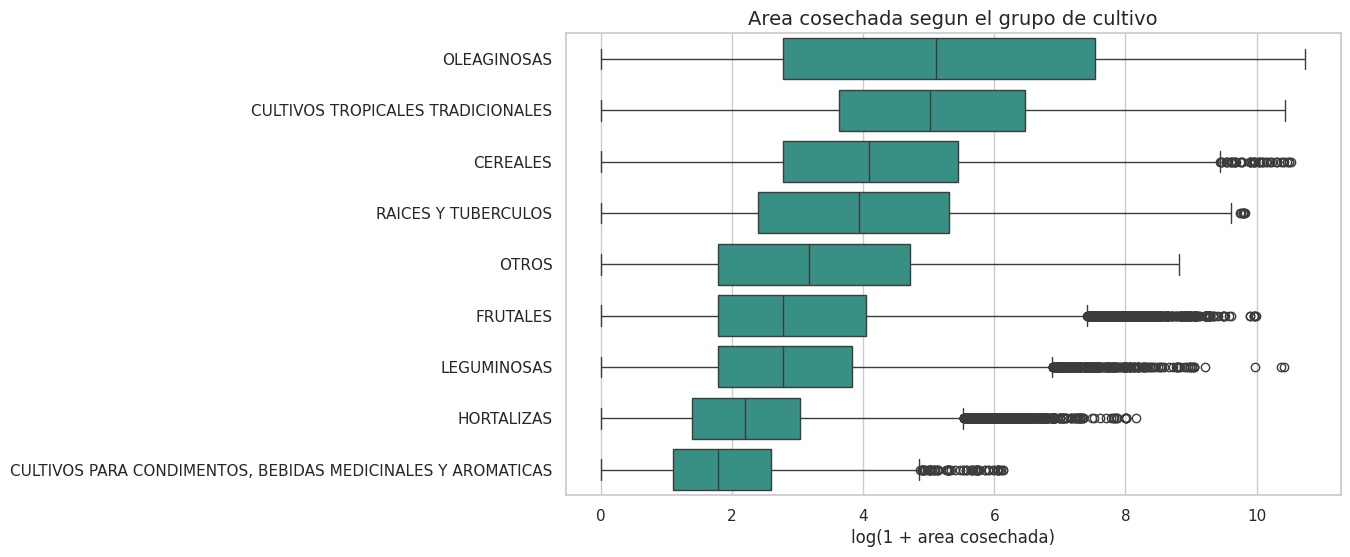

Mediana del area cosechada por grupo (hectareas):
grupo
OLEAGINOSAS                                                   165.00
CULTIVOS TROPICALES TRADICIONALES                             150.00
CEREALES                                                       59.00
RAICES Y TUBERCULOS                                            50.00
OTROS                                                          23.00
FRUTALES                                                       15.00
LEGUMINOSAS                                                    15.00
HORTALIZAS                                                      8.00
CULTIVOS PARA CONDIMENTOS, BEBIDAS MEDICINALES Y AROMATICAS     5.00
Name: area_cosechada, dtype: float64


In [ ]:
# Area cosechada segun el grupo de cultivo (usamos la escala logaritmica para que se vea bien)
datos_limpios["area_log"] = np.log1p(datos_limpios["area_cosechada"])
orden = datos_limpios.groupby("grupo")["area_cosechada"].median().sort_values(ascending=False).index

plt.figure(figsize=(10, 6))
sns.boxplot(data=datos_limpios, y="grupo", x="area_log", order=orden, color=VERDE)
plt.title("Area cosechada segun el grupo de cultivo")
plt.xlabel("log(1 + area cosechada)")
plt.ylabel("")
plt.show()

print("Mediana del area cosechada por grupo (hectareas):")
print(datos_limpios.groupby("grupo")["area_cosechada"].median().sort_values(ascending=False))

In [ ]:
# Grafica interactiva: evolucion de los 5 cultivos principales
top_5 = datos_limpios.groupby("cultivo")["area_cosechada"].sum().nlargest(5).index
datos_top5 = datos_limpios[datos_limpios["cultivo"].isin(top_5)]
evolucion = datos_top5.groupby(["anio", "cultivo"], as_index=False)["area_cosechada"].sum()

figura = px.line(evolucion, x="anio", y="area_cosechada", color="cultivo", markers=True,
                 title="Evolucion del area cosechada de los 5 cultivos principales",
                 labels={"anio": "Anio", "area_cosechada": "Area cosechada (hectareas)",
                         "cultivo": "Cultivo"})
figura.show()

## 6.5 Relaciones entre las variables

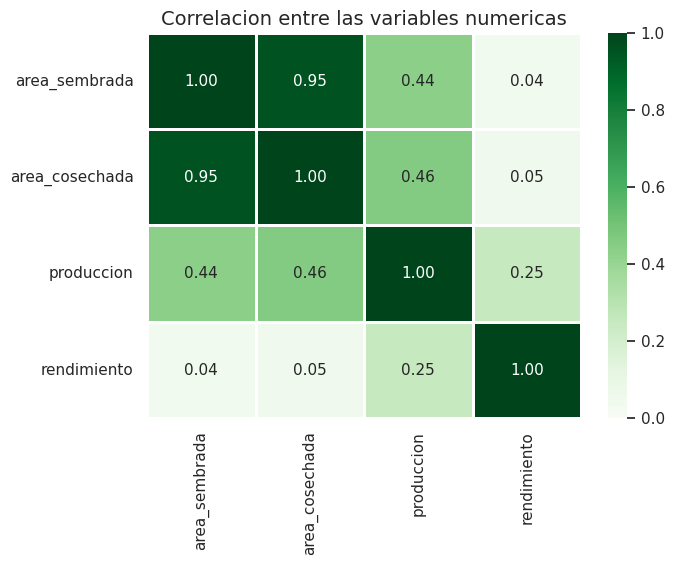

La correlacion va de 0 a 1: entre mas cerca de 1, mas relacionadas estan.

Correlacion de cada variable con el area cosechada:
area_cosechada   1.00
area_sembrada    0.95
produccion       0.46
rendimiento      0.05
Name: area_cosechada, dtype: float64


In [ ]:
# Correlacion entre las variables numericas
variables = datos_limpios[["area_sembrada", "area_cosechada", "produccion", "rendimiento"]]
correlacion = variables.corr()

plt.figure(figsize=(7, 5))
sns.heatmap(correlacion, annot=True, cmap="Greens", vmin=0, vmax=1,
            linewidths=1, fmt=".2f")
plt.title("Correlacion entre las variables numericas")
plt.show()

print("La correlacion va de 0 a 1: entre mas cerca de 1, mas relacionadas estan.")
print()
print("Correlacion de cada variable con el area cosechada:")
print(correlacion["area_cosechada"].sort_values(ascending=False))

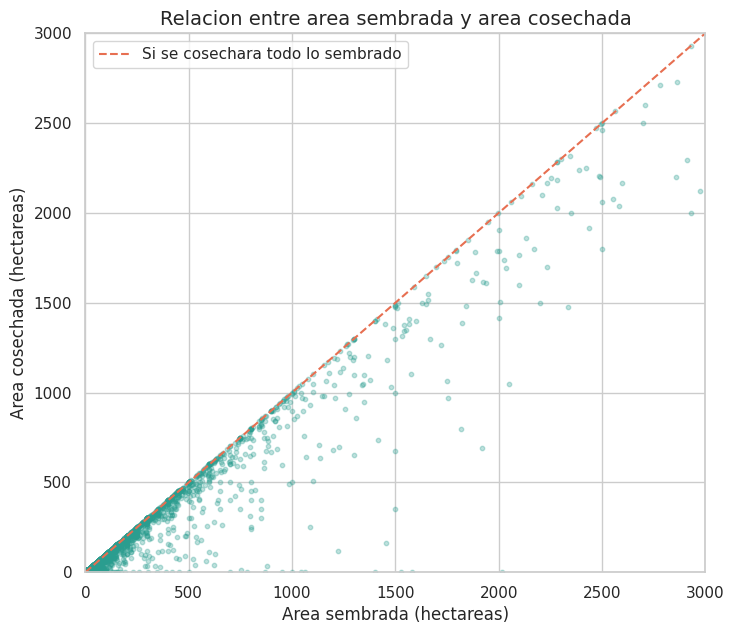

En el 48.9 % de las filas se cosechó exactamente lo mismo que se sembro.
Por eso casi todos los puntos caen sobre la linea naranja.
Esto significa que el area sembrada es el mejor predictor que tenemos.


In [ ]:
# La relacion mas fuerte es area sembrada con area cosechada. La vemos en un grafico de dispersion.
muestra = datos_limpios.sample(5000, random_state=1)

plt.figure(figsize=(8, 7))
plt.scatter(muestra["area_sembrada"], muestra["area_cosechada"],
            s=10, alpha=0.3, color=VERDE)
plt.plot([0, 20000], [0, 20000], color=NARANJA, linestyle="--",
         label="Si se cosechara todo lo sembrado")
plt.xlim(0, 3000)
plt.ylim(0, 3000)
plt.title("Relacion entre area sembrada y area cosechada")
plt.xlabel("Area sembrada (hectareas)")
plt.ylabel("Area cosechada (hectareas)")
plt.legend()
plt.show()

iguales = (datos_limpios["area_sembrada"] == datos_limpios["area_cosechada"]).mean() * 100
print("En el", round(iguales, 1), "% de las filas se cosechó exactamente lo mismo que se sembro.")
print("Por eso casi todos los puntos caen sobre la linea naranja.")
print("Esto significa que el area sembrada es el mejor predictor que tenemos.")

---
# 7. Conclusiones y proximos pasos

## Lo que encontramos

**Sobre los datos**

1. Los dos archivos se pudieron unir sin problema despues de renombrar las columnas, convertir
   los numeros y arreglar los nombres de los departamentos. Quedo una tabla de mas de 370.000
   filas con 20 anios de informacion (2006 a 2025).
2. La variable objetivo no tiene datos faltantes. Aparecieron 254 filas repetidas al quedarnos
   con menos columnas y las eliminamos.

**Sobre la variable objetivo**

3. El area cosechada es una variable **muy asimetrica**: la mediana es de 23 hectareas pero el
   maximo llega a 77.630. Por eso la reportamos con mediana y rango intercuartil.
4. Usando el logaritmo la distribucion se vuelve una campana, lo que sera util para el modelo.
5. Revisamos los valores mas altos uno por uno: algunos eran errores (la soya de Puerto Gaitan)
   y otros eran reales (la palma de Puerto Wilches). Borramos los primeros y conservamos los
   segundos.

**Sobre la calidad**

6. Encontramos filas imposibles y las eliminamos, pero son pocas comparadas con el total.
7. Los problemas no estan repartidos igual entre los dos archivos: el archivo nuevo tiene
   muchas mas filas con area cosechada mayor que la sembrada. Cambio la forma de reportar.

**Sobre los patrones**

8. El **area sembrada** es la variable mas relacionada con el area cosechada.
9. En casi la mitad de las filas el area cosechada es exactamente igual a la sembrada, lo que
   indica que en muchos municipios copian el dato.
10. El tipo de cultivo influye mas que el departamento: los cereales y las oleaginosas ocupan
    areas mucho mas grandes que las hortalizas.

## Que sigue en la Fase 2

1. Decidir si trabajamos con todos los anios o solo con el archivo nuevo (2019-2025).
2. Decidir que hacer con las filas donde el area cosechada es cero.
3. Recalcular el rendimiento que falta en el archivo viejo.
4. Convertir las variables de texto (cultivo, departamento) en numeros para poder usarlas en el
   modelo.
5. Entrenar el modelo usando el logaritmo del area cosechada.
6. Usar algoritmos geneticos para elegir automaticamente las mejores variables del modelo.
7. Separar los datos por anio para entrenar y probar (no de forma aleatoria, porque los datos
   son de una linea de tiempo).

## Limitaciones

- No unificamos los nombres de los cultivos entre los dos archivos. El archivo viejo separa
  "CANA AZUCARERA" y "CANA PANELERA" mientras el nuevo tiene solo "CANA". Para comparar los dos
  periodos es mejor usar la columna `grupo`.
- Las EVA son estimaciones hechas por cada municipio, no mediciones exactas.

In [ ]:
# =========================================================
# Guardamos la tabla limpia en Drive para usarla en la Fase 2
# =========================================================
# Quitamos las columnas auxiliares que creamos durante el analisis
datos_limpios = datos_limpios.drop(columns=["problema_1", "problema_2", "problema_3", "area_log"])

datos_limpios.to_csv(RUTA + "eva_limpio.csv", index=False)

print("Archivo guardado en:", RUTA + "eva_limpio.csv")
print("Filas guardadas    :", len(datos_limpios))
print("Columnas guardadas :", len(datos_limpios.columns))

Archivo guardado en: /content/drive/MyDrive/EVA/eva_limpio.csv
Filas guardadas    : 354505
Columnas guardadas : 13
